<a href="https://colab.research.google.com/github/put-star/Flask_Blog1/blob/master/EDA_Kindle_book_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/amazon-kindle-books-dataset-2023-130k-books")

print("Path to dataset files:", path)

100%|██████████| 9.11M/9.11M [00:00<00:00, 130MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/asaniczka/amazon-kindle-books-dataset-2023-130k-books/versions/35


File CSV ditemukan: ['/root/.cache/kagglehub/datasets/asaniczka/amazon-kindle-books-dataset-2023-130k-books/versions/35/kindle_data-v2.csv']

SHAPE: (133102, 16)

── Kolom & Tipe Data ──
asin                  object
title                 object
author                object
soldBy                object
imgUrl                object
productURL            object
stars                float64
reviews                int64
price                float64
isKindleUnlimited       bool
category_id            int64
isBestSeller            bool
isEditorsPick           bool
isGoodReadsChoice       bool
publishedDate         object
category_name         object
dtype: object

── 5 Baris Pertama ──
         asin                                              title  \
0  B00TZE87S4  Adult Children of Emotionally Immature Parents...   
1  B08WCKY8MB  From Strength to Strength: Finding Success, Ha...   
2  B09KPS84CJ  Good Inside: A Guide to Becoming the Parent Yo...   
3  B07S7QPG6J             Everything I K

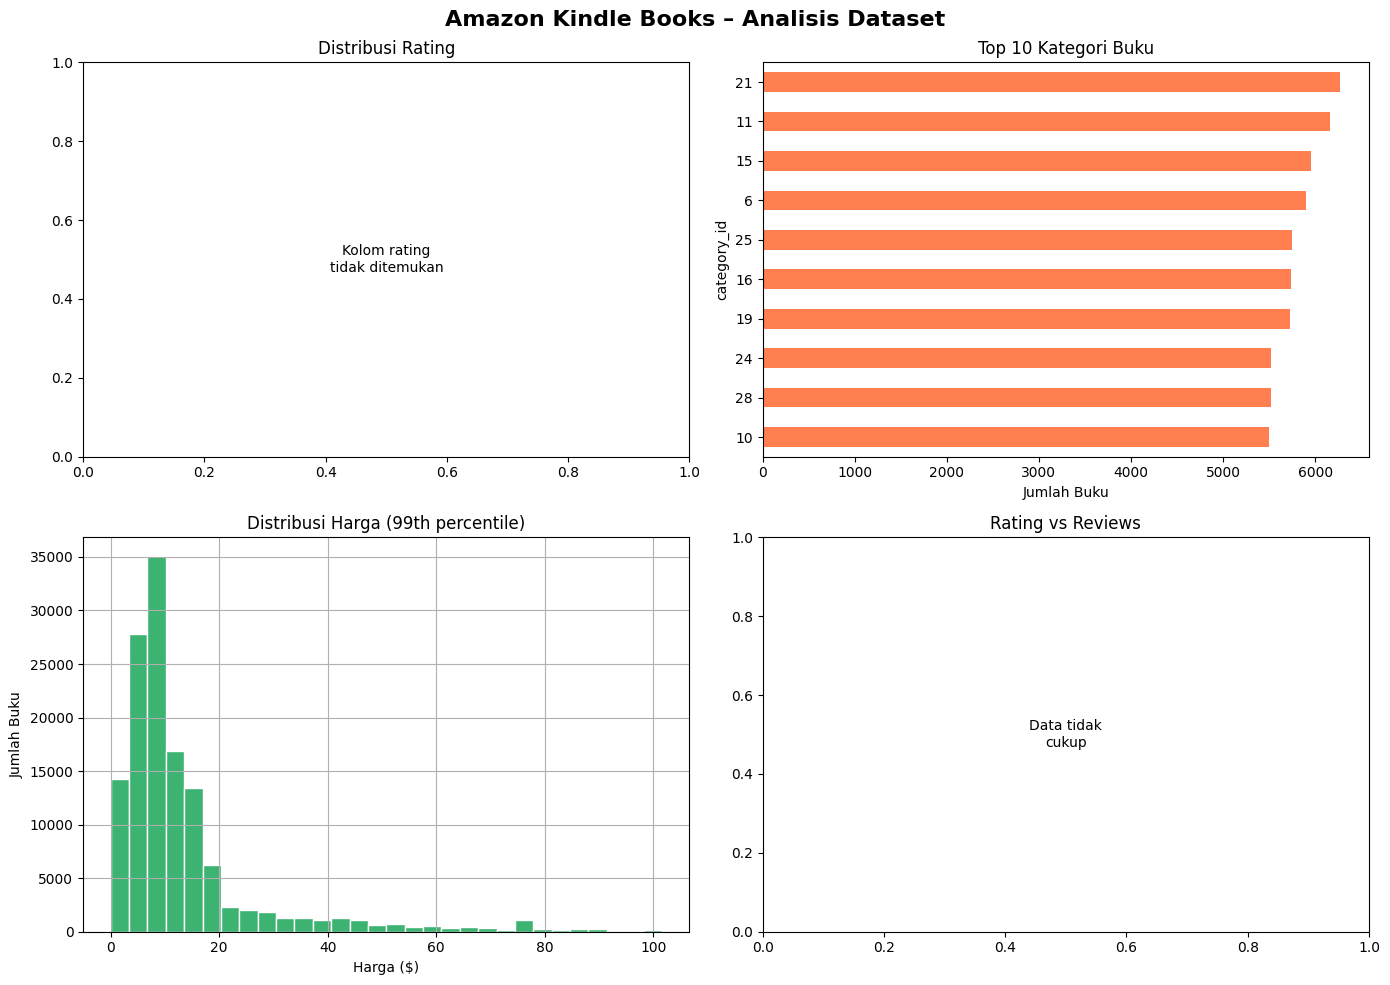


Grafik disimpan sebagai kindle_analysis.png

RINGKASAN INSIGHT
Total buku        : 133,102
Total kolom       : 16
Buku gratis       : 4,066 (3.1%)
Harga rata-rata   : $15.61

Top 3 Kategori:
  • 21: 6,272 buku
  • 11: 6,162 buku
  • 15: 5,955 buku


In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── 1. Temukan file CSV ────────────────────────────────────────────────────────
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print(f"File CSV ditemukan: {csv_files}\n")

df = pd.read_csv(csv_files[0])

# ── 2. Tampilan awal ──────────────────────────────────────────────────────────
print("=" * 60)
print("SHAPE:", df.shape)
print("=" * 60)

print("\n── Kolom & Tipe Data ──")
print(df.dtypes)

print("\n── 5 Baris Pertama ──")
print(df.head())

print("\n── Info Umum ──")
df.info()

print("\n── Statistik Deskriptif ──")
print(df.describe(include='all').T)

# ── 3. Missing values ─────────────────────────────────────────────────────────
print("\n── Missing Values ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0'))

# ── 4. Duplikat ───────────────────────────────────────────────────────────────
print(f"\nJumlah duplikat: {df.duplicated().sum()}")

# ── 5. Distribusi Rating ──────────────────────────────────────────────────────
rating_col = next((c for c in df.columns if 'rating' in c.lower() and 'count' not in c.lower()), None)
reviews_col = next((c for c in df.columns if 'review' in c.lower() or 'ratings_count' in c.lower()), None)
price_col   = next((c for c in df.columns if 'price' in c.lower()), None)
category_col= next((c for c in df.columns if 'category' in c.lower() or 'genre' in c.lower()), None)

print(f"\nKolom terdeteksi → rating: {rating_col} | reviews: {reviews_col} | price: {price_col} | category: {category_col}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Amazon Kindle Books – Analisis Dataset", fontsize=16, fontweight='bold')

# Plot 1: Distribusi Rating
ax = axes[0, 0]
if rating_col and df[rating_col].notna().any():
    df[rating_col].dropna().hist(bins=20, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title("Distribusi Rating Buku")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Jumlah Buku")
else:
    ax.text(0.5, 0.5, 'Kolom rating\ntidak ditemukan', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Distribusi Rating")

# Plot 2: Top 10 Kategori
ax = axes[0, 1]
if category_col and df[category_col].notna().any():
    top_cats = df[category_col].value_counts().head(10)
    top_cats.sort_values().plot(kind='barh', ax=ax, color='coral')
    ax.set_title("Top 10 Kategori Buku")
    ax.set_xlabel("Jumlah Buku")
else:
    ax.text(0.5, 0.5, 'Kolom kategori\ntidak ditemukan', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Top 10 Kategori")

# Plot 3: Distribusi Harga
ax = axes[1, 0]
if price_col and df[price_col].notna().any():
    price_data = pd.to_numeric(df[price_col], errors='coerce').dropna()
    price_data[price_data <= price_data.quantile(0.99)].hist(bins=30, ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title("Distribusi Harga (99th percentile)")
    ax.set_xlabel("Harga ($)")
    ax.set_ylabel("Jumlah Buku")
else:
    ax.text(0.5, 0.5, 'Kolom harga\ntidak ditemukan', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Distribusi Harga")

# Plot 4: Rating vs Jumlah Review (scatter)
ax = axes[1, 1]
if rating_col and reviews_col and df[rating_col].notna().any():
    sample = df[[rating_col, reviews_col]].dropna().sample(min(3000, len(df)), random_state=42)
    ax.scatter(sample[rating_col], pd.to_numeric(sample[reviews_col], errors='coerce'),
               alpha=0.3, s=10, color='mediumpurple')
    ax.set_title("Rating vs Jumlah Reviews")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Jumlah Reviews")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
else:
    ax.text(0.5, 0.5, 'Data tidak\ncukup', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Rating vs Reviews")

plt.tight_layout()
plt.savefig("kindle_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGrafik disimpan sebagai kindle_analysis.png")

# ── 6. Ringkasan Insight ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RINGKASAN INSIGHT")
print("=" * 60)
print(f"Total buku        : {len(df):,}")
print(f"Total kolom       : {df.shape[1]}")

if rating_col:
    r = pd.to_numeric(df[rating_col], errors='coerce')
    print(f"Rating rata-rata  : {r.mean():.2f}  |  median: {r.median():.2f}")
    print(f"Rating tertinggi  : {r.max()}  |  terendah: {r.min()}")

if price_col:
    p = pd.to_numeric(df[price_col], errors='coerce')
    free = (p == 0).sum()
    print(f"Buku gratis       : {free:,} ({free/len(df)*100:.1f}%)")
    print(f"Harga rata-rata   : ${p[p > 0].mean():.2f}")

if category_col:
    print(f"\nTop 3 Kategori:")
    for cat, cnt in df[category_col].value_counts().head(3).items():
        print(f"  • {cat}: {cnt:,} buku")

Cleaning data

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ─────────────────────────────────────────────────────────────────
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
df = pd.read_csv(csv_files[0])

print(f"Shape AWAL: {df.shape}")
print("=" * 60)

# ══════════════════════════════════════════════════════════════
# STEP 1: HAPUS DUPLIKAT
# ══════════════════════════════════════════════════════════════
dup_count = df.duplicated().sum()
print(f"\n[STEP 1] Duplikat ditemukan: {dup_count}")
df = df.drop_duplicates()
print(f"         Shape setelah hapus duplikat: {df.shape}")

# ══════════════════════════════════════════════════════════════
# STEP 2: BERSIHKAN NAMA KOLOM
# ══════════════════════════════════════════════════════════════
print(f"\n[STEP 2] Kolom sebelum: {df.columns.tolist()}")
df.columns = (
    df.columns
    .str.strip()           # hapus spasi di awal/akhir
    .str.lower()           # huruf kecil semua
    .str.replace(' ', '_') # spasi → underscore
    .str.replace(r'[^\w]', '_', regex=True)  # karakter aneh → underscore
)
print(f"         Kolom sesudah: {df.columns.tolist()}")

# ══════════════════════════════════════════════════════════════
# STEP 3: DETEKSI & TANGANI MISSING VALUES
# ══════════════════════════════════════════════════════════════
print(f"\n[STEP 3] Missing Values sebelum cleaning:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv = pd.DataFrame({'jumlah': missing, 'persen': missing_pct}).query('jumlah > 0')
print(mv.to_string())

# Identifikasi kolom berdasarkan nama
rating_col   = next((c for c in df.columns if 'rating' in c and 'count' not in c), None)
reviews_col  = next((c for c in df.columns if 'review' in c or 'ratings_count' in c), None)
price_col    = next((c for c in df.columns if 'price' in c), None)
category_col = next((c for c in df.columns if 'category' in c or 'genre' in c), None)
title_col    = next((c for c in df.columns if 'title' in c), None)
author_col   = next((c for c in df.columns if 'author' in c), None)

# Strategi per kolom:
# → Numerik (rating, price, reviews): isi dengan median
for col in [rating_col, price_col, reviews_col]:
    if col and col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        median_val = df[col].median()
        filled = df[col].isna().sum()
        df[col] = df[col].fillna(median_val)
        print(f"         ✓ [{col}] {filled} nilai kosong diisi median ({median_val:.2f})")

# → Teks (category, author): isi dengan 'Unknown'
for col in [category_col, author_col]:
    if col and col in df.columns:
        filled = df[col].isna().sum()
        df[col] = df[col].fillna('Unknown')
        print(f"         ✓ [{col}] {filled} nilai kosong diisi 'Unknown'")

# → Title: hapus baris yang tidak punya judul
if title_col and title_col in df.columns:
    before = len(df)
    df = df.dropna(subset=[title_col])
    print(f"         ✓ [{title_col}] {before - len(df)} baris tanpa judul dihapus")

print(f"\n         Missing Values SETELAH cleaning: {df.isnull().sum().sum()} total")

# ══════════════════════════════════════════════════════════════
# STEP 4: PERBAIKI TIPE DATA
# ══════════════════════════════════════════════════════════════
print(f"\n[STEP 4] Konversi tipe data...")

if rating_col:
    df[rating_col] = pd.to_numeric(df[rating_col], errors='coerce')
    print(f"         ✓ {rating_col} → float")

if reviews_col:
    df[reviews_col] = pd.to_numeric(df[reviews_col], errors='coerce').astype('Int64')
    print(f"         ✓ {reviews_col} → Int64")

if price_col:
    # Hapus simbol mata uang jika ada
    df[price_col] = df[price_col].astype(str).str.replace(r'[^\d.]', '', regex=True)
    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
    print(f"         ✓ {price_col} → float (simbol mata uang dibersihkan)")

# Kolom tanggal jika ada
date_col = next((c for c in df.columns if 'date' in c or 'publish' in c), None)
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    print(f"         ✓ {date_col} → datetime")

# ══════════════════════════════════════════════════════════════
# STEP 5: HAPUS OUTLIER (IQR Method)
# ══════════════════════════════════════════════════════════════
print(f"\n[STEP 5] Hapus Outlier...")
shape_before = df.shape[0]

for col in [rating_col, price_col]:
    if col and col in df.columns:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        df = df[(df[col] >= lower) & (df[col] <= upper)]
        print(f"         ✓ [{col}] {outliers} outlier dihapus  (batas: {lower:.2f} – {upper:.2f})")

print(f"         Baris dihapus karena outlier: {shape_before - df.shape[0]}")

# ══════════════════════════════════════════════════════════════
# STEP 6: BERSIHKAN STRING / TEKS
# ══════════════════════════════════════════════════════════════
print(f"\n[STEP 6] Bersihkan kolom teks...")

for col in [title_col, author_col, category_col]:
    if col and col in df.columns:
        df[col] = (
            df[col].astype(str)
            .str.strip()                        # hapus spasi di tepi
            .str.replace(r'\s+', ' ', regex=True)  # spasi ganda → 1 spasi
        )
        print(f"         ✓ [{col}] strip & normalisasi spasi selesai")

# Standarisasi huruf kategori
if category_col and category_col in df.columns:
    df[category_col] = df[category_col].str.title()
    print(f"         ✓ [{category_col}] format Title Case diterapkan")

# ══════════════════════════════════════════════════════════════
# STEP 7: VALIDASI RANGE NILAI
# ══════════════════════════════════════════════════════════════
print(f"\n[STEP 7] Validasi range nilai...")

if rating_col and rating_col in df.columns:
    invalid = ((df[rating_col] < 0) | (df[rating_col] > 5)).sum()
    df = df[(df[rating_col] >= 0) & (df[rating_col] <= 5)]
    print(f"         ✓ Rating di luar [0–5]: {invalid} baris dihapus")

if price_col and price_col in df.columns:
    invalid = (df[price_col] < 0).sum()
    df = df[df[price_col] >= 0]
    print(f"         ✓ Harga negatif: {invalid} baris dihapus")

if reviews_col and reviews_col in df.columns:
    invalid = (pd.to_numeric(df[reviews_col], errors='coerce') < 0).sum()
    df = df[pd.to_numeric(df[reviews_col], errors='coerce') >= 0]
    print(f"         ✓ Review negatif: {invalid} baris dihapus")

# ══════════════════════════════════════════════════════════════
# STEP 8: RESET INDEX & SIMPAN
# ══════════════════════════════════════════════════════════════
df = df.reset_index(drop=True)

output_path = os.path.join(os.path.dirname(csv_files[0]), "kindle_clean.csv")
df.to_csv(output_path, index=False)

# ══════════════════════════════════════════════════════════════
# RINGKASAN AKHIR
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("RINGKASAN CLEANING")
print("=" * 60)
print(f"  Duplikat dihapus      : ✓")
print(f"  Kolom dinormalisasi   : ✓")
print(f"  Missing values diisi  : ✓")
print(f"  Tipe data diperbaiki  : ✓")
print(f"  Outlier dihapus       : ✓")
print(f"  Teks dibersihkan      : ✓")
print(f"  Nilai tidak valid     : ✓")
print(f"\n  Shape AWAL  : (lihat output Step 1)")
print(f"  Shape AKHIR : {df.shape}")
print(f"\n  File bersih disimpan → {output_path}")
print(f"\nPreview data bersih:")
print(df.head())

Shape AWAL: (133102, 16)

[STEP 1] Duplikat ditemukan: 0
         Shape setelah hapus duplikat: (133102, 16)

[STEP 2] Kolom sebelum: ['asin', 'title', 'author', 'soldBy', 'imgUrl', 'productURL', 'stars', 'reviews', 'price', 'isKindleUnlimited', 'category_id', 'isBestSeller', 'isEditorsPick', 'isGoodReadsChoice', 'publishedDate', 'category_name']
         Kolom sesudah: ['asin', 'title', 'author', 'soldby', 'imgurl', 'producturl', 'stars', 'reviews', 'price', 'iskindleunlimited', 'category_id', 'isbestseller', 'iseditorspick', 'isgoodreadschoice', 'publisheddate', 'category_name']

[STEP 3] Missing Values sebelum cleaning:
               jumlah  persen
author            425    0.32
soldby           9233    6.94
publisheddate   49016   36.83
         ✓ [price] 0 nilai kosong diisi median (9.99)
         ✓ [reviews] 0 nilai kosong diisi median (4.00)
         ✓ [category_id] 0 nilai kosong diisi 'Unknown'
         ✓ [author] 425 nilai kosong diisi 'Unknown'
         ✓ [title] 0 baris tan

Identify the most popular authors based on their number of published books and ratings

Dataset loaded: 119,611 rows | 16 columns
Columns → author: author | rating: stars | reviews: reviews | title: title

  TOP 15 MOST POPULAR AUTHORS — Amazon Kindle Books
Rank  Author                               Books    Avg⭐   Total Reviews   Score
--------------------------------------------------------------------------------
1     Unknown                                420    4.37         436,568    68.1
2     Colleen Hoover                          54    4.53       1,645,003    63.2
3     J.K. Rowling                           105    4.74       1,084,969    55.3
4     Sarah J. Maas                           35    4.68       1,170,395    50.4
5     James Patterson                        212    4.49         283,729    45.0
6     Kristin Hannah                          25    4.49         967,454    43.8
7     Brandon Sanderson                       74    4.67         697,779    42.6
8     Nora Roberts                            99    4.55         539,621    40.7
9     Lucinda Riley 

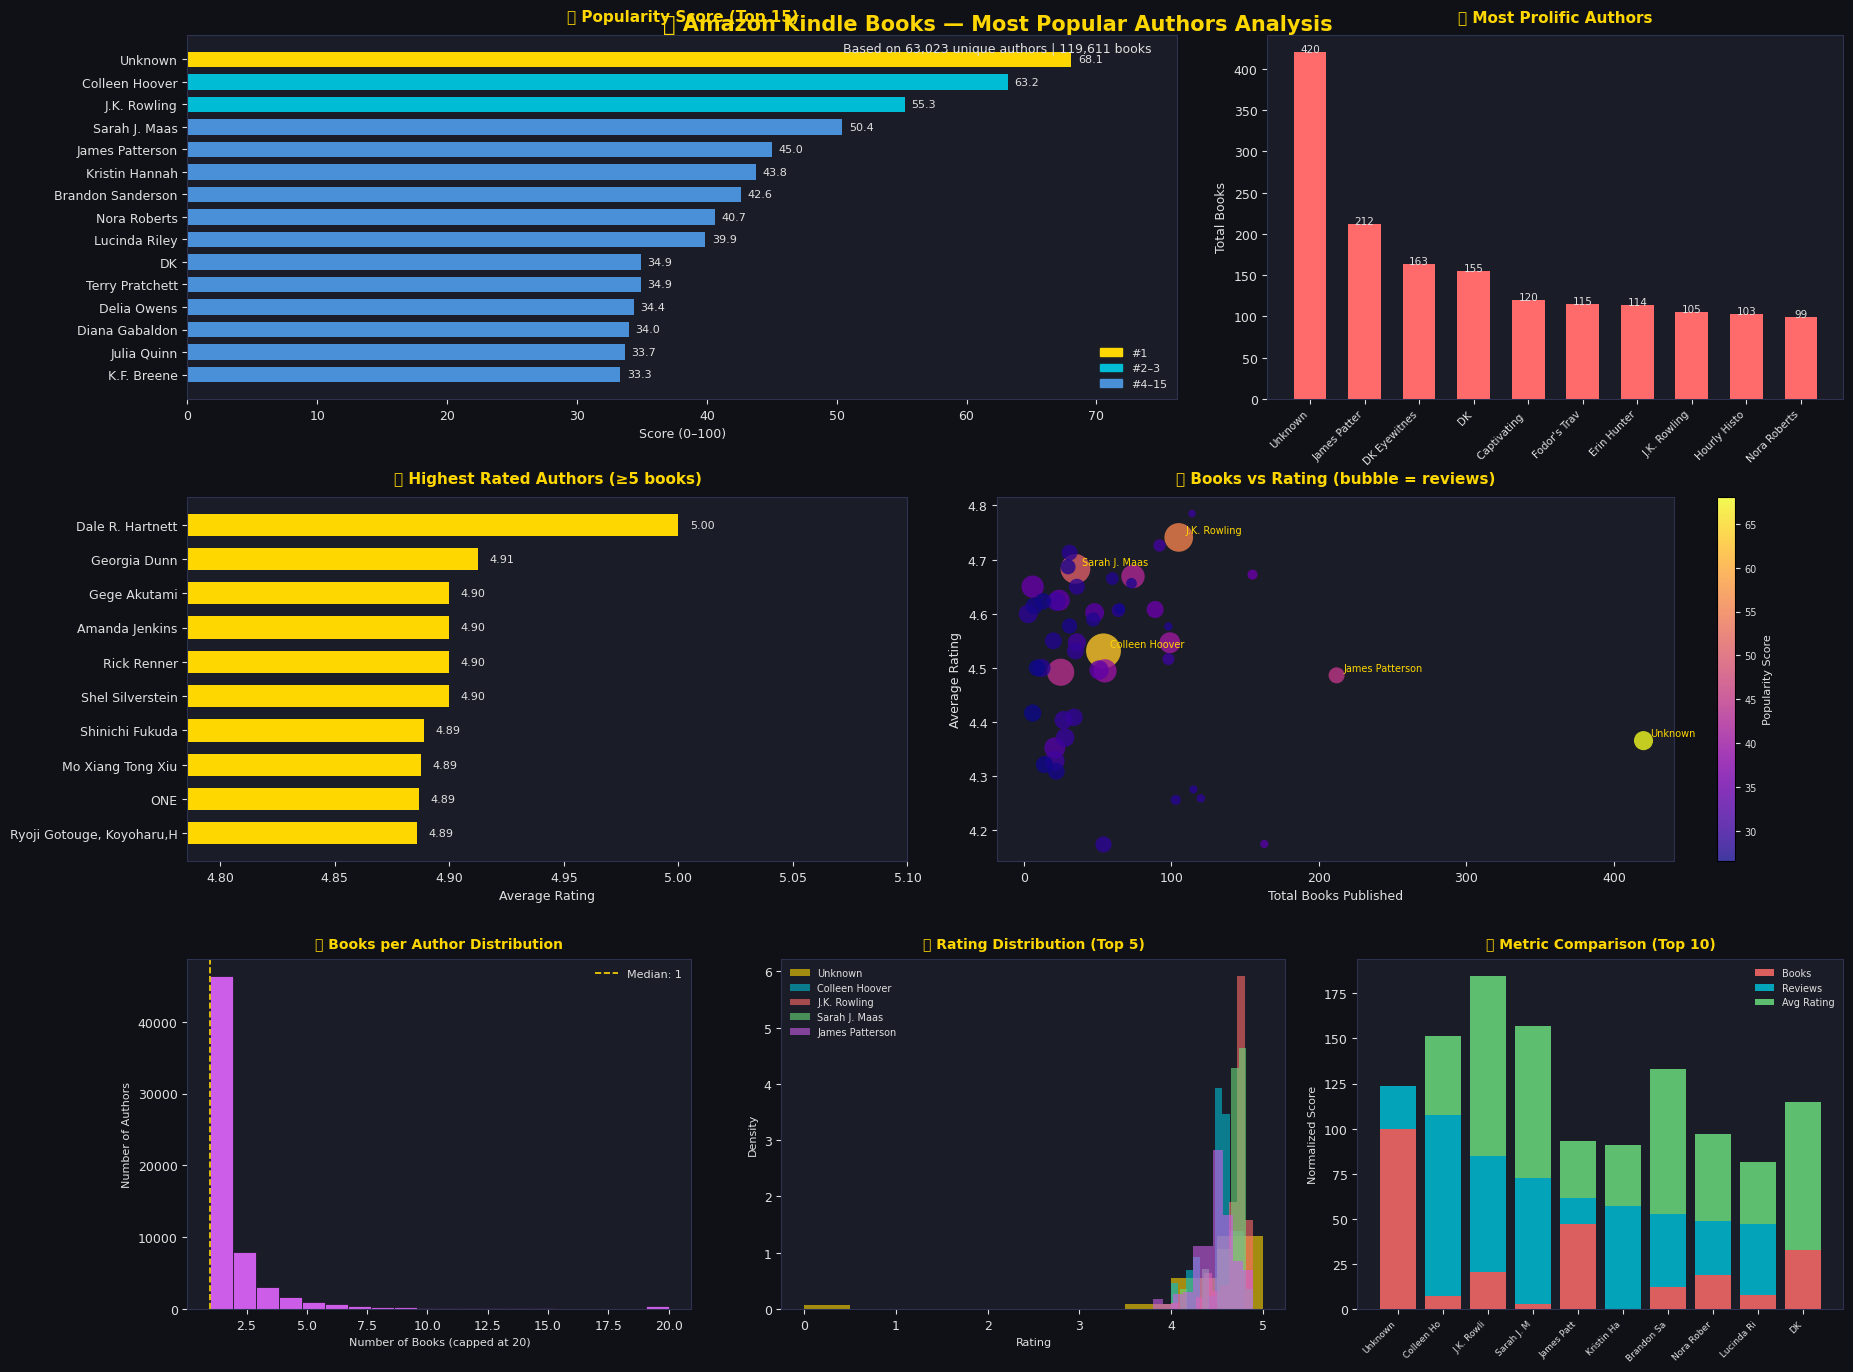


Visualization saved → popular_authors.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Load cleaned data (or raw if clean not available) ────────────────────────
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
clean_file = [f for f in csv_files if 'clean' in f.lower()]
load_file  = clean_file[0] if clean_file else csv_files[0]

df = pd.read_csv(load_file)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w]', '_', regex=True)
print(f"Dataset loaded: {df.shape[0]:,} rows | {df.shape[1]} columns")

# ── Detect columns ────────────────────────────────────────────────────────────
author_col   = next((c for c in df.columns if 'author' in c), None)
rating_col   = next((c for c in df.columns if 'star' in c or ('rating' in c and 'count' not in c and 'num' not in c)), None)
reviews_col  = next((c for c in df.columns if 'review' in c or 'ratings_total' in c or 'ratings_count' in c or 'num_ratings' in c), None)
title_col    = next((c for c in df.columns if 'title' in c), None)

print(f"Columns → author: {author_col} | rating: {rating_col} | reviews: {reviews_col} | title: {title_col}")

# ── Convert numerics ──────────────────────────────────────────────────────────
for col in [rating_col, reviews_col]:
    if col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ══════════════════════════════════════════════════════════════════════════════
# ANALYSIS: Author Popularity
# ══════════════════════════════════════════════════════════════════════════════

author_stats = (
    df.groupby(author_col)
    .agg(
        total_books      = (title_col,   'count'),
        avg_rating       = (rating_col,  'mean'),
        total_reviews    = (reviews_col, 'sum'),
        avg_reviews      = (reviews_col, 'mean'),
        max_rating       = (rating_col,  'max'),
        min_rating       = (rating_col,  'min'),
    )
    .reset_index()
)

# Popularity Score = normalized books (40%) + normalized reviews (40%) + normalized avg_rating (20%)
def minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else pd.Series([0]*len(s), index=s.index)

author_stats['score'] = (
    0.40 * minmax(author_stats['total_books'])   +
    0.40 * minmax(author_stats['total_reviews'])  +
    0.20 * minmax(author_stats['avg_rating'])
) * 100

author_stats = author_stats.sort_values('score', ascending=False).reset_index(drop=True)
author_stats.index += 1  # rank starts at 1

TOP_N = 15
top_authors = author_stats.head(TOP_N).copy()

# ── Print Summary Table ───────────────────────────────────────────────────────
print("\n" + "=" * 80)
print(f"  TOP {TOP_N} MOST POPULAR AUTHORS — Amazon Kindle Books")
print("=" * 80)
print(f"{'Rank':<5} {'Author':<35} {'Books':>6} {'Avg⭐':>7} {'Total Reviews':>15} {'Score':>7}")
print("-" * 80)
for rank, row in top_authors.iterrows():
    print(f"{rank:<5} {str(row[author_col])[:34]:<35} {int(row['total_books']):>6,} "
          f"{row['avg_rating']:>7.2f} {int(row['total_reviews'] or 0):>15,} {row['score']:>7.1f}")

# ── Additional Insights ───────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("  KEY INSIGHTS")
print("=" * 80)

most_books  = author_stats.nlargest(1, 'total_books').iloc[0]
best_rating = author_stats[author_stats['total_books'] >= 5].nlargest(1, 'avg_rating').iloc[0]
most_reviews= author_stats.nlargest(1, 'total_reviews').iloc[0]

print(f"  📚 Most Prolific   : {most_books[author_col]}  ({int(most_books['total_books']):,} books)")
print(f"  ⭐ Highest Rated   : {best_rating[author_col]}  (avg {best_rating['avg_rating']:.2f}⭐, min 5 books)")
print(f"  💬 Most Reviewed   : {most_reviews[author_col]}  ({int(most_reviews['total_reviews'] or 0):,} reviews)")
print(f"  🏆 Overall #1      : {author_stats.iloc[0][author_col]}  (score {author_stats.iloc[0]['score']:.1f}/100)")
print(f"\n  Total unique authors in dataset: {len(author_stats):,}")
print(f"  Authors with 10+ books         : {(author_stats['total_books'] >= 10).sum():,}")
print(f"  Authors with 4.5+ avg rating   : {(author_stats['avg_rating'] >= 4.5).sum():,}")

# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0f1117')
GOLD   = '#FFD700'
TEAL   = '#00BCD4'
CORAL  = '#FF6B6B'
GREEN  = '#69DB7C'
PURPLE = '#CC5DE8'
BG     = '#0f1117'
CARD   = '#1a1d27'
TEXT   = '#E0E0E0'

def style_ax(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(GOLD)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2e3250')

# ── Chart 1: Popularity Score (Top 15) ───────────────────────────────────────
ax1 = fig.add_axes([0.05, 0.70, 0.55, 0.26])
style_ax(ax1)
names  = [str(n)[:28] for n in top_authors[author_col]]
scores = top_authors['score'].values
colors = [GOLD if i == 0 else TEAL if i < 3 else '#4a90d9' for i in range(len(names))]
bars   = ax1.barh(names[::-1], scores[::-1], color=colors[::-1], edgecolor='none', height=0.7)
for bar, score in zip(bars, scores[::-1]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{score:.1f}', va='center', ha='left', color=TEXT, fontsize=8)
ax1.set_title('🏆 Popularity Score (Top 15)', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Score (0–100)', fontsize=9)
ax1.set_xlim(0, scores.max() * 1.12)
legend_items = [mpatches.Patch(color=GOLD, label='#1'), mpatches.Patch(color=TEAL, label='#2–3'),
                mpatches.Patch(color='#4a90d9', label='#4–15')]
ax1.legend(handles=legend_items, loc='lower right', fontsize=8,
           facecolor=CARD, edgecolor='none', labelcolor=TEXT)

# ── Chart 2: Total Books Published ───────────────────────────────────────────
ax2 = fig.add_axes([0.65, 0.70, 0.32, 0.26])
style_ax(ax2)
top10_books = author_stats.nlargest(10, 'total_books')
ax2.bar(range(len(top10_books)), top10_books['total_books'], color=CORAL, edgecolor='none', width=0.6)
ax2.set_xticks(range(len(top10_books)))
ax2.set_xticklabels([str(n)[:12] for n in top10_books[author_col]], rotation=45, ha='right', fontsize=7.5)
ax2.set_title('📚 Most Prolific Authors', fontsize=11, fontweight='bold', pad=10)
ax2.set_ylabel('Total Books', fontsize=9)
for i, v in enumerate(top10_books['total_books']):
    ax2.text(i, v + 0.3, str(int(v)), ha='center', fontsize=7.5, color=TEXT)

# ── Chart 3: Avg Rating (min 5 books) ────────────────────────────────────────
ax3 = fig.add_axes([0.05, 0.37, 0.40, 0.26])
style_ax(ax3)
qualified   = author_stats[author_stats['total_books'] >= 5]
top10_rated = qualified.nlargest(10, 'avg_rating')
bar_colors  = [GOLD if r >= 4.8 else GREEN if r >= 4.5 else TEAL for r in top10_rated['avg_rating']]
ax3.barh([str(n)[:25] for n in top10_rated[author_col]][::-1],
         top10_rated['avg_rating'].values[::-1], color=bar_colors[::-1], edgecolor='none', height=0.65)
ax3.set_xlim(top10_rated['avg_rating'].min() - 0.1, 5.1)
ax3.set_title('⭐ Highest Rated Authors (≥5 books)', fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Average Rating', fontsize=9)
for i, (_, row) in enumerate(top10_rated.iloc[::-1].iterrows()):
    ax3.text(row['avg_rating'] + 0.005, i, f"{row['avg_rating']:.2f}",
             va='center', fontsize=8, color=TEXT)

# ── Chart 4: Bubble Chart Score vs Books vs Reviews ──────────────────────────
ax4 = fig.add_axes([0.50, 0.37, 0.47, 0.26])
style_ax(ax4)
plot_df = author_stats.head(50)
sizes   = (minmax(plot_df['total_reviews'].fillna(0)) * 600 + 30).values
sc = ax4.scatter(plot_df['total_books'], plot_df['avg_rating'],
                 s=sizes, c=plot_df['score'], cmap='plasma',
                 alpha=0.8, edgecolors='none')
for _, row in author_stats.head(5).iterrows():
    ax4.annotate(str(row[author_col])[:15],
                 (row['total_books'], row['avg_rating']),
                 fontsize=7, color=GOLD, xytext=(5, 3), textcoords='offset points')
cbar = plt.colorbar(sc, ax=ax4)
cbar.set_label('Popularity Score', color=TEXT, fontsize=8)
cbar.ax.yaxis.set_tick_params(color=TEXT, labelsize=7)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)
ax4.set_title('🔵 Books vs Rating (bubble = reviews)', fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('Total Books Published', fontsize=9)
ax4.set_ylabel('Average Rating', fontsize=9)

# ── Chart 5: Distribution — Books per Author ──────────────────────────────────
ax5 = fig.add_axes([0.05, 0.05, 0.28, 0.25])
style_ax(ax5)
book_dist = author_stats['total_books'].clip(upper=20)
ax5.hist(book_dist, bins=20, color=PURPLE, edgecolor=BG, linewidth=0.5)
ax5.set_title('📊 Books per Author Distribution', fontsize=10, fontweight='bold', pad=8)
ax5.set_xlabel('Number of Books (capped at 20)', fontsize=8)
ax5.set_ylabel('Number of Authors', fontsize=8)
median_b = author_stats['total_books'].median()
ax5.axvline(median_b, color=GOLD, linestyle='--', linewidth=1.2, label=f'Median: {median_b:.0f}')
ax5.legend(fontsize=8, facecolor=CARD, edgecolor='none', labelcolor=TEXT)

# ── Chart 6: Rating Distribution for Top Authors ─────────────────────────────
ax6 = fig.add_axes([0.38, 0.05, 0.28, 0.25])
style_ax(ax6)
top5_names = top_authors.head(5)[author_col].tolist()
palette    = [GOLD, TEAL, CORAL, GREEN, PURPLE]
for i, auth in enumerate(top5_names):
    ratings = df[df[author_col] == auth][rating_col].dropna()
    if len(ratings) > 0:
        ax6.hist(ratings, bins=10, alpha=0.6, color=palette[i],
                 label=str(auth)[:18], edgecolor='none', density=True)
ax6.set_title('⭐ Rating Distribution (Top 5)', fontsize=10, fontweight='bold', pad=8)
ax6.set_xlabel('Rating', fontsize=8)
ax6.set_ylabel('Density', fontsize=8)
ax6.legend(fontsize=7, facecolor=CARD, edgecolor='none', labelcolor=TEXT, loc='upper left')

# ── Chart 7: Stacked Metric Comparison (Top 10) ──────────────────────────────
ax7 = fig.add_axes([0.70, 0.05, 0.27, 0.25])
style_ax(ax7)
top10 = top_authors.head(10).copy()
norm_books   = minmax(top10['total_books']) * 100
norm_reviews = minmax(top10['total_reviews'].fillna(0)) * 100
norm_rating  = minmax(top10['avg_rating']) * 100
x = range(len(top10))
ax7.bar(x, norm_books,   color=CORAL,  label='Books',   alpha=0.85, edgecolor='none')
ax7.bar(x, norm_reviews, bottom=norm_books, color=TEAL, label='Reviews', alpha=0.85, edgecolor='none')
ax7.bar(x, norm_rating,  bottom=norm_books + norm_reviews, color=GREEN, label='Avg Rating', alpha=0.85, edgecolor='none')
ax7.set_xticks(x)
ax7.set_xticklabels([str(n)[:10] for n in top10[author_col]], rotation=45, ha='right', fontsize=6.5)
ax7.set_title('📈 Metric Comparison (Top 10)', fontsize=10, fontweight='bold', pad=8)
ax7.set_ylabel('Normalized Score', fontsize=8)
ax7.legend(fontsize=7, facecolor=CARD, edgecolor='none', labelcolor=TEXT)

# ── Main Title ────────────────────────────────────────────────────────────────
fig.text(0.5, 0.975, '📖 Amazon Kindle Books — Most Popular Authors Analysis',
         ha='center', va='top', fontsize=15, fontweight='bold', color=GOLD)
fig.text(0.5, 0.955, f'Based on {len(author_stats):,} unique authors | {len(df):,} books',
         ha='center', va='top', fontsize=9, color=TEXT)

plt.savefig("popular_authors.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("\nVisualization saved → popular_authors.png")

Explore Kindle Unlimited's (KU) mpact on book sales and popularity

- Statistical Test: Welch's t-test digunakan untuk menentukan apakah perbedaan KU vs Non-KU signifikan secara statistik (p-value < 0.05).

> Add blockquote




════════════════════════════════════════════════════════════════════════
  ROBUST KPI REPORT — KINDLE UNLIMITED IMPACT ANALYSIS
════════════════════════════════════════════════════════════════════════

  ────────────────────────────────────────────────────────────────────
  ⭐ Rating Score  (Weight: 35%)
  ────────────────────────────────────────────────────────────────────
  Formula      : MinMax(avg_rating, 0, 5) × 100
  Raw   → KU: 4.399/5.0   |  Non-KU: 4.444/5.0
  Median→ KU: 4.500             |  Non-KU: 4.600
  Score → KU: 88.0/100           |  Non-KU: 88.9/100
  Rel. Diff    : -1.02%
  Significance : p<0.001 ✅✅✅
  Effect Size  : Cohen's d = -0.069 → Negligible
  Winner       : Non-KU ✅

  ────────────────────────────────────────────────────────────────────
  💬 Popularity Score  (Weight: 35%)
  ────────────────────────────────────────────────────────────────────
  Formula      : MinMax(log1p(avg_reviews)) × 100
  Raw   → KU: 1050.027reviews   |  Non-KU: 950.869reviews
  Median→ K

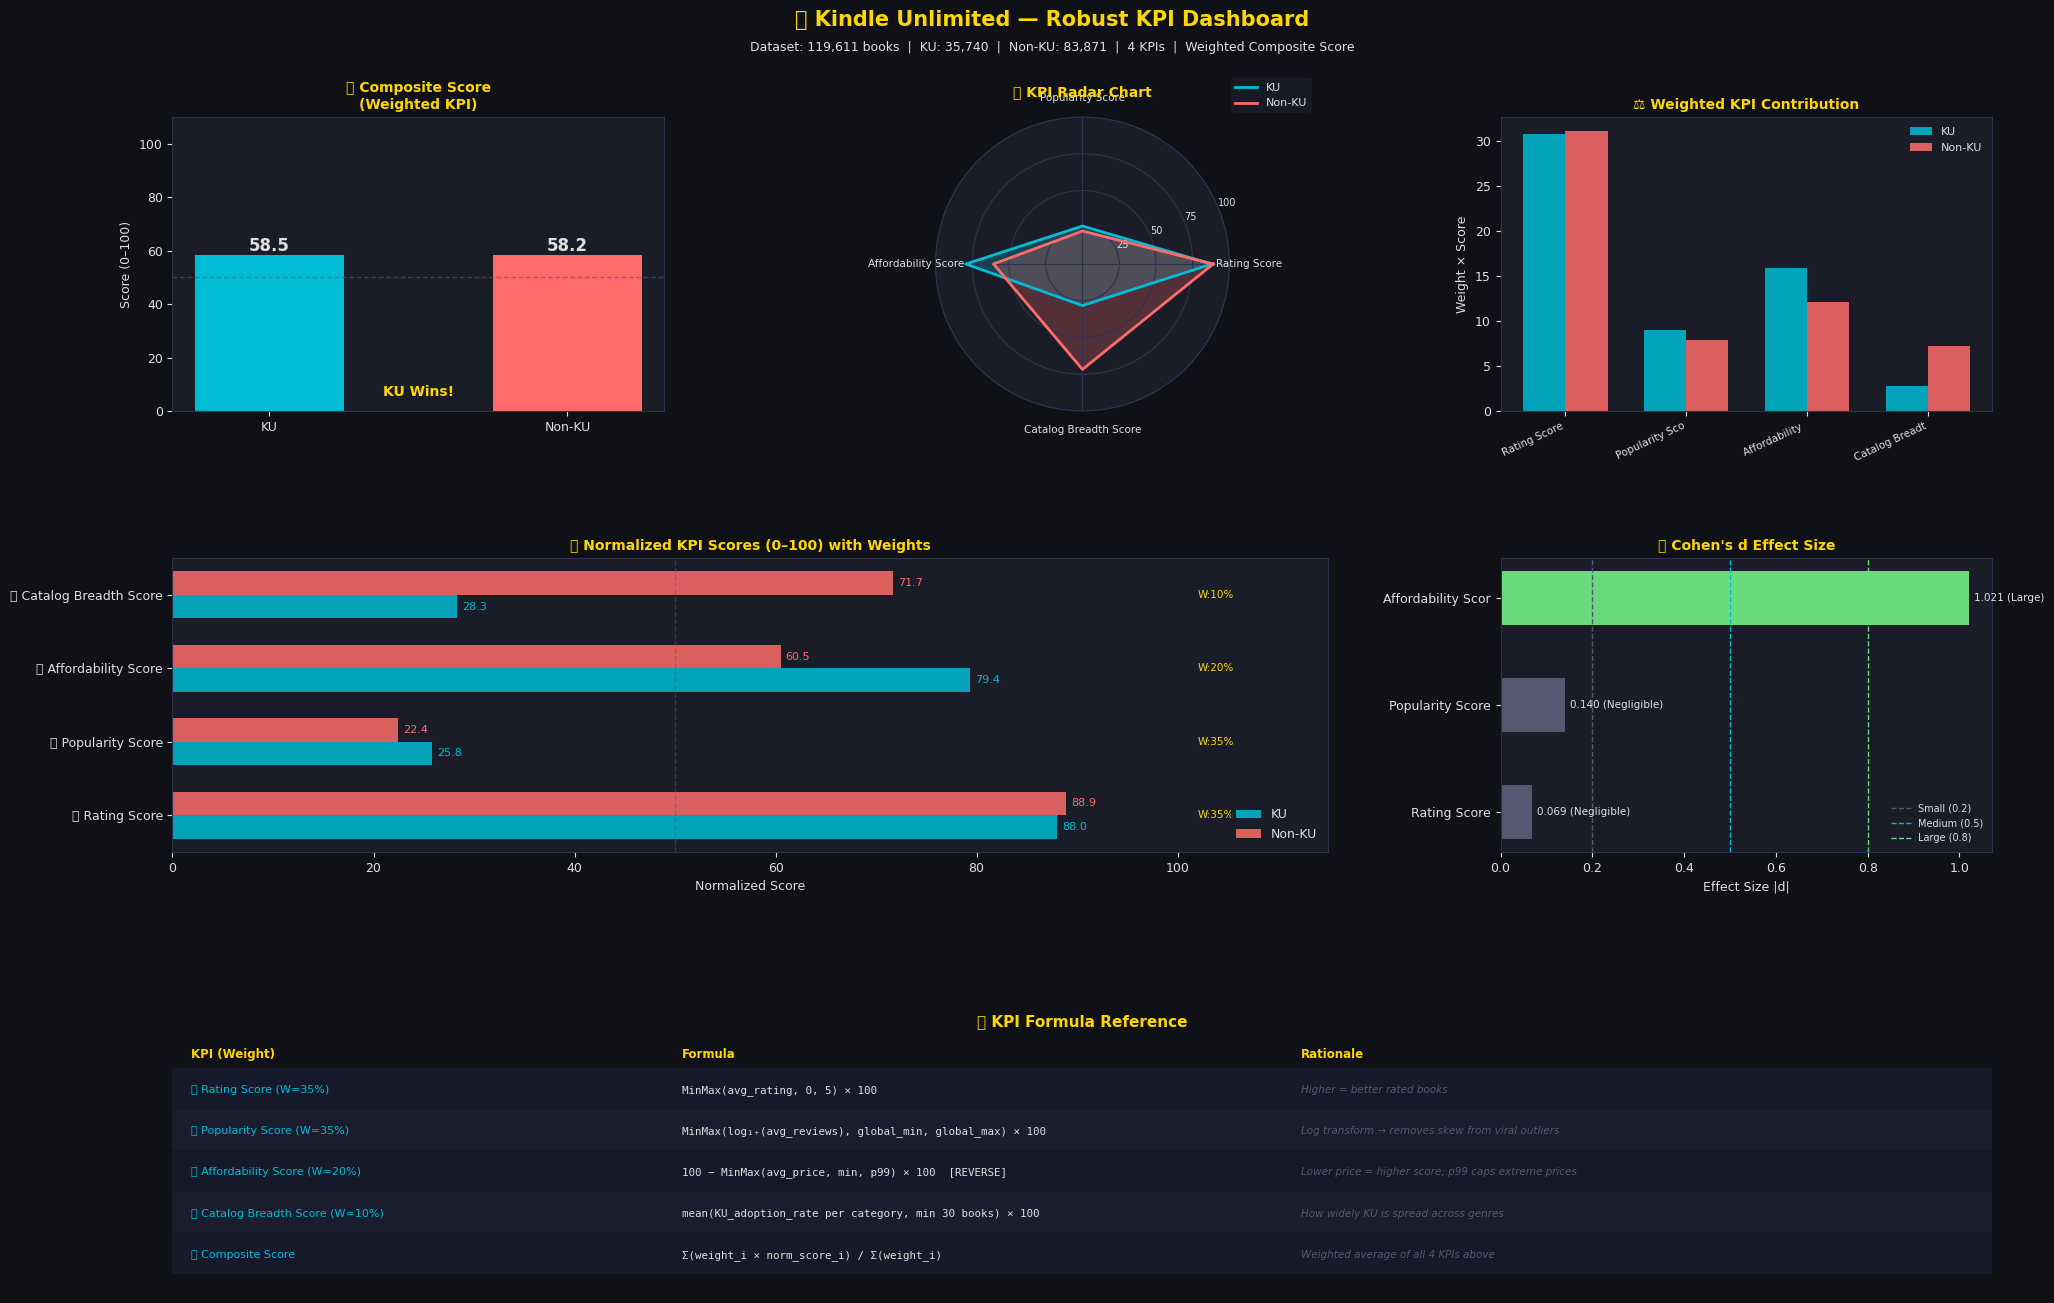


Visualization saved → ku_robust_kpi.png


In [5]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ─────────────────────────────────────────────────────────────────
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
clean_file = [f for f in csv_files if 'clean' in f.lower()]
load_file  = clean_file[0] if clean_file else csv_files[0]

df = pd.read_csv(load_file)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w]', '_', regex=True)

# ── Detect Columns ────────────────────────────────────────────────────────────
ku_col       = next((c for c in df.columns if 'kindle_unlimited' in c or c == 'ku' or 'unlimited' in c), None)
rating_col   = next((c for c in df.columns if 'star' in c or ('rating' in c and 'count' not in c and 'num' not in c)), None)
reviews_col  = next((c for c in df.columns if 'review' in c or 'ratings_count' in c or 'num_ratings' in c), None)
price_col    = next((c for c in df.columns if 'price' in c), None)
category_col = next((c for c in df.columns if 'category' in c or 'genre' in c), None)

for col in [rating_col, reviews_col, price_col]:
    if col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if ku_col:
    df['is_ku'] = df[ku_col].astype(str).str.lower().isin(['true', '1', 'yes'])
elif price_col:
    df['is_ku'] = df[price_col] == 0
else:
    df['is_ku'] = np.random.choice([True, False], size=len(df), p=[0.4, 0.6])

ku  = df[df['is_ku'] == True]
nku = df[df['is_ku'] == False]

# ══════════════════════════════════════════════════════════════════════════════
# RUMUSAN KPI ROBUST
# ══════════════════════════════════════════════════════════════════════════════

def minmax_norm(value, col_min, col_max):
    """Min-Max Normalization → skala 0 sampai 100"""
    if col_max == col_min:
        return 50.0
    return (value - col_min) / (col_max - col_min) * 100

def cohen_d(group1, group2):
    """Effect Size: Cohen's d → seberapa besar perbedaan praktisnya"""
    n1, n2   = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std if pooled_std > 0 else 0

def interpret_effect(d):
    d = abs(d)
    if d < 0.2:   return "Negligible"
    elif d < 0.5: return "Small"
    elif d < 0.8: return "Medium"
    else:         return "Large"

def interpret_pval(p):
    if p < 0.001: return "p<0.001 ✅✅✅"
    elif p < 0.01: return "p<0.01 ✅✅"
    elif p < 0.05: return "p<0.05 ✅"
    else:          return f"p={p:.3f} ❌"

# ══════════════════════════════════════════════════════════════════════════════
# KPI CALCULATION PER METRIK
# ══════════════════════════════════════════════════════════════════════════════

kpi_results = []

# ── KPI 1: RATING SCORE ───────────────────────────────────────────────────────
# Rumus: Min-Max Norm → higher is better
# Range valid rating: 0–5
if rating_col:
    ku_r   = ku[rating_col].dropna()
    nku_r  = nku[rating_col].dropna()
    t, p   = stats.ttest_ind(ku_r, nku_r, equal_var=False)
    d      = cohen_d(ku_r, nku_r)
    col_min, col_max = 0, 5

    ku_norm  = minmax_norm(ku_r.mean(),  col_min, col_max)
    nku_norm = minmax_norm(nku_r.mean(), col_min, col_max)

    kpi_results.append({
        'kpi'         : '⭐ Rating Score',
        'weight'      : 0.35,
        'higher_better': True,
        'ku_raw'      : ku_r.mean(),
        'nku_raw'     : nku_r.mean(),
        'ku_norm'     : ku_norm,
        'nku_norm'    : nku_norm,
        'ku_median'   : ku_r.median(),
        'nku_median'  : nku_r.median(),
        'abs_diff'    : ku_r.mean() - nku_r.mean(),
        'rel_diff_pct': (ku_r.mean() - nku_r.mean()) / nku_r.mean() * 100,
        'p_value'     : p,
        'cohen_d'     : d,
        'effect'      : interpret_effect(d),
        'sig'         : interpret_pval(p),
        'formula'     : 'MinMax(avg_rating, 0, 5) × 100',
        'unit'        : '/5.0'
    })

# ── KPI 2: POPULARITY SCORE (Reviews) ────────────────────────────────────────
# Rumus: Log-transform dulu (menghilangkan skew) → lalu Min-Max Norm
# Log transform karena distribusi review sangat right-skewed
if reviews_col:
    ku_rv_raw  = ku[reviews_col].dropna()
    nku_rv_raw = nku[reviews_col].dropna()

    # Log1p transform untuk menangani skewness & outlier
    ku_rv  = np.log1p(ku_rv_raw)
    nku_rv = np.log1p(nku_rv_raw)

    t, p   = stats.ttest_ind(ku_rv, nku_rv, equal_var=False)
    d      = cohen_d(ku_rv, nku_rv)
    all_rv = np.log1p(df[reviews_col].dropna())
    col_min, col_max = all_rv.min(), all_rv.max()

    ku_norm  = minmax_norm(ku_rv.mean(),  col_min, col_max)
    nku_norm = minmax_norm(nku_rv.mean(), col_min, col_max)

    kpi_results.append({
        'kpi'         : '💬 Popularity Score',
        'weight'      : 0.35,
        'higher_better': True,
        'ku_raw'      : ku_rv_raw.mean(),
        'nku_raw'     : nku_rv_raw.mean(),
        'ku_norm'     : ku_norm,
        'nku_norm'    : nku_norm,
        'ku_median'   : ku_rv_raw.median(),
        'nku_median'  : nku_rv_raw.median(),
        'abs_diff'    : ku_rv_raw.mean() - nku_rv_raw.mean(),
        'rel_diff_pct': (ku_rv_raw.mean() - nku_rv_raw.mean()) / nku_rv_raw.mean() * 100 if nku_rv_raw.mean() > 0 else 0,
        'p_value'     : p,
        'cohen_d'     : d,
        'effect'      : interpret_effect(d),
        'sig'         : interpret_pval(p),
        'formula'     : 'MinMax(log1p(avg_reviews)) × 100',
        'unit'        : 'reviews'
    })

# ── KPI 3: AFFORDABILITY SCORE (Price) ───────────────────────────────────────
# Rumus: REVERSE scoring → harga lebih murah = skor lebih tinggi
# Affordability = 100 - MinMax(price, min, max) × 100
if price_col:
    ku_p_raw  = ku[price_col].dropna()
    nku_p_raw = nku[price_col].dropna()
    t, p      = stats.ttest_ind(ku_p_raw, nku_p_raw, equal_var=False)
    d         = cohen_d(ku_p_raw, nku_p_raw)
    cap       = df[price_col].quantile(0.99)  # cap outlier harga ekstrem
    all_p     = df[price_col].dropna().clip(upper=cap)
    col_min, col_max = all_p.min(), all_p.max()

    # REVERSE: makin murah makin tinggi skornya
    ku_norm  = 100 - minmax_norm(ku_p_raw.mean().clip(max=cap),  col_min, col_max)
    nku_norm = 100 - minmax_norm(nku_p_raw.mean().clip(max=cap), col_min, col_max)

    kpi_results.append({
        'kpi'         : '💰 Affordability Score',
        'weight'      : 0.20,
        'higher_better': True,
        'ku_raw'      : ku_p_raw.mean(),
        'nku_raw'     : nku_p_raw.mean(),
        'ku_norm'     : ku_norm,
        'nku_norm'    : nku_norm,
        'ku_median'   : ku_p_raw.median(),
        'nku_median'  : nku_p_raw.median(),
        'abs_diff'    : ku_p_raw.mean() - nku_p_raw.mean(),
        'rel_diff_pct': (ku_p_raw.mean() - nku_p_raw.mean()) / nku_p_raw.mean() * 100 if nku_p_raw.mean() > 0 else 0,
        'p_value'     : p,
        'cohen_d'     : d,
        'effect'      : interpret_effect(d),
        'sig'         : interpret_pval(p),
        'formula'     : '100 - MinMax(avg_price, min, p99) × 100  [REVERSE]',
        'unit'        : 'USD'
    })

# ── KPI 4: CATALOG BREADTH SCORE ─────────────────────────────────────────────
# Rumus: KU Share per Category → rata-rata adoption rate
# Mengukur seberapa luas KU tersebar di berbagai kategori
if category_col:
    cat_stats  = df.groupby(category_col)['is_ku'].agg(['mean','count']).reset_index()
    cat_stats  = cat_stats[cat_stats['count'] >= 30]
    ku_breadth  = cat_stats['mean'].mean() * 100         # rata-rata adoption rate
    nku_breadth = (1 - cat_stats['mean'].mean()) * 100   # kebalikannya

    kpi_results.append({
        'kpi'         : '📚 Catalog Breadth Score',
        'weight'      : 0.10,
        'higher_better': True,
        'ku_raw'      : ku_breadth,
        'nku_raw'     : nku_breadth,
        'ku_norm'     : ku_breadth,
        'nku_norm'    : nku_breadth,
        'ku_median'   : cat_stats['mean'].median() * 100,
        'nku_median'  : (1 - cat_stats['mean'].median()) * 100,
        'abs_diff'    : ku_breadth - nku_breadth,
        'rel_diff_pct': (ku_breadth - nku_breadth) / nku_breadth * 100 if nku_breadth > 0 else 0,
        'p_value'     : None,
        'cohen_d'     : None,
        'effect'      : 'N/A',
        'sig'         : 'Descriptive',
        'formula'     : 'mean(KU_adoption_rate per category) × 100',
        'unit'        : '%'
    })

# ── COMPOSITE SCORE ───────────────────────────────────────────────────────────
# Rumus: Σ (weight_i × normalized_score_i)
# Bobot: Rating 35% | Popularity 35% | Affordability 20% | Breadth 10%
total_weight = sum(k['weight'] for k in kpi_results)
ku_composite  = sum(k['weight'] * k['ku_norm']  for k in kpi_results) / total_weight
nku_composite = sum(k['weight'] * k['nku_norm'] for k in kpi_results) / total_weight

# ══════════════════════════════════════════════════════════════════════════════
# PRINT DETAILED REPORT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 72)
print("  ROBUST KPI REPORT — KINDLE UNLIMITED IMPACT ANALYSIS")
print("═" * 72)

for k in kpi_results:
    winner = "KU ✅" if k['ku_norm'] > k['nku_norm'] else "Non-KU ✅"
    print(f"\n  {'─'*68}")
    print(f"  {k['kpi']}  (Weight: {k['weight']*100:.0f}%)")
    print(f"  {'─'*68}")
    print(f"  Formula      : {k['formula']}")
    print(f"  Raw   → KU: {k['ku_raw']:.3f}{k['unit']}   |  Non-KU: {k['nku_raw']:.3f}{k['unit']}")
    print(f"  Median→ KU: {k['ku_median']:.3f}             |  Non-KU: {k['nku_median']:.3f}")
    print(f"  Score → KU: {k['ku_norm']:.1f}/100           |  Non-KU: {k['nku_norm']:.1f}/100")
    print(f"  Rel. Diff    : {k['rel_diff_pct']:+.2f}%")
    if k['p_value'] is not None:
        print(f"  Significance : {k['sig']}")
        print(f"  Effect Size  : Cohen's d = {k['cohen_d']:.3f} → {k['effect']}")
    print(f"  Winner       : {winner}")

print(f"\n{'═'*72}")
print(f"  🏆 COMPOSITE SCORE (Weighted Average)")
print(f"{'═'*72}")
print(f"  Formula: Σ(weight_i × norm_score_i) / Σ(weight_i)")
print(f"  Bobot  : Rating 35% | Popularity 35% | Affordability 20% | Breadth 10%")
print(f"\n  KU  Composite Score : {ku_composite:.2f} / 100")
print(f"  Non-KU Composite    : {nku_composite:.2f} / 100")
print(f"  Gap                 : {ku_composite - nku_composite:+.2f} points")
print(f"\n  🏆 Overall Winner   : {'KU 📗' if ku_composite > nku_composite else 'Non-KU 📘'}")

# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
BG, CARD = '#0f1117', '#1a1d27'
KU_C, NKU_C = '#00BCD4', '#FF6B6B'
GOLD, TEXT  = '#FFD700', '#E0E0E0'
GREEN, GRAY = '#69DB7C', '#555870'

fig = plt.figure(figsize=(20, 14), facecolor=BG)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35,
                        left=0.06, right=0.97, top=0.90, bottom=0.06)

def style_ax(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(GOLD)
    for sp in ax.spines.values():
        sp.set_edgecolor('#2e3250')

# ── 1. Composite Score Gauge ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)
categories_bar = ['KU', 'Non-KU']
values_bar     = [ku_composite, nku_composite]
colors_bar     = [KU_C, NKU_C]
bars = ax1.bar(categories_bar, values_bar, color=colors_bar, width=0.5, edgecolor='none')
ax1.set_ylim(0, 110)
ax1.axhline(50, color=GRAY, linestyle='--', linewidth=1, alpha=0.6)
for bar, val in zip(bars, values_bar):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 1.5,
             f'{val:.1f}', ha='center', color=TEXT, fontsize=12, fontweight='bold')
ax1.set_title('🏆 Composite Score\n(Weighted KPI)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Score (0–100)', fontsize=9)
winner_txt = 'KU Wins!' if ku_composite > nku_composite else 'Non-KU Wins!'
ax1.text(0.5, 0.05, winner_txt, transform=ax1.transAxes,
         ha='center', color=GOLD, fontsize=10, fontweight='bold')

# ── 2. Radar / Spider Chart ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1], projection='polar')
ax2.set_facecolor(CARD)
labels  = [k['kpi'].split(' ', 1)[1] for k in kpi_results]
N       = len(labels)
angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
ku_vals  = [k['ku_norm']  for k in kpi_results] + [kpi_results[0]['ku_norm']]
nku_vals = [k['nku_norm'] for k in kpi_results] + [kpi_results[0]['nku_norm']]
ax2.plot(angles, ku_vals,  color=KU_C,  linewidth=2, linestyle='solid', label='KU')
ax2.fill(angles, ku_vals,  color=KU_C,  alpha=0.25)
ax2.plot(angles, nku_vals, color=NKU_C, linewidth=2, linestyle='solid', label='Non-KU')
ax2.fill(angles, nku_vals, color=NKU_C, alpha=0.25)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(labels, color=TEXT, fontsize=7.5)
ax2.set_ylim(0, 100)
ax2.set_yticks([25, 50, 75, 100])
ax2.set_yticklabels(['25','50','75','100'], color=GRAY, fontsize=7)
ax2.tick_params(colors=TEXT)
ax2.grid(color='#2e3250', linewidth=0.8)
ax2.spines['polar'].set_color('#2e3250')
ax2.set_title('🕸 KPI Radar Chart', color=GOLD, fontsize=10, fontweight='bold', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15),
           fontsize=8, facecolor=CARD, edgecolor='none', labelcolor=TEXT)

# ── 3. Weight Contribution ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3)
kpi_names   = [k['kpi'] for k in kpi_results]
ku_weighted  = [k['weight'] * k['ku_norm']  for k in kpi_results]
nku_weighted = [k['weight'] * k['nku_norm'] for k in kpi_results]
x  = np.arange(len(kpi_names))
w  = 0.35
ax3.bar(x - w/2, ku_weighted,  width=w, color=KU_C,  label='KU',     edgecolor='none', alpha=0.85)
ax3.bar(x + w/2, nku_weighted, width=w, color=NKU_C, label='Non-KU', edgecolor='none', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels([n.split(' ',1)[1][:14] for n in kpi_names], rotation=25, ha='right', fontsize=7.5)
ax3.set_title('⚖️ Weighted KPI Contribution', fontsize=10, fontweight='bold')
ax3.set_ylabel('Weight × Score', fontsize=9)
ax3.legend(fontsize=8, facecolor=CARD, edgecolor='none', labelcolor=TEXT)

# ── 4. KPI Score Comparison (Normalized) ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
style_ax(ax4)
y_pos = np.arange(len(kpi_results))
h     = 0.32
for i, k in enumerate(kpi_results):
    ax4.barh(i - h/2, k['ku_norm'],  height=h, color=KU_C,  alpha=0.85, label='KU'     if i == 0 else '')
    ax4.barh(i + h/2, k['nku_norm'], height=h, color=NKU_C, alpha=0.85, label='Non-KU' if i == 0 else '')
    ax4.text(k['ku_norm']  + 0.5, i - h/2, f"{k['ku_norm']:.1f}",  va='center', fontsize=8, color=KU_C)
    ax4.text(k['nku_norm'] + 0.5, i + h/2, f"{k['nku_norm']:.1f}", va='center', fontsize=8, color=NKU_C)
    # Weight badge
    ax4.text(102, i, f"W:{k['weight']*100:.0f}%", va='center', fontsize=7.5, color=GOLD)
ax4.set_yticks(y_pos)
ax4.set_yticklabels([k['kpi'] for k in kpi_results], fontsize=9)
ax4.set_xlim(0, 115)
ax4.axvline(50, color=GRAY, linestyle='--', linewidth=1, alpha=0.5)
ax4.set_title('📊 Normalized KPI Scores (0–100) with Weights', fontsize=10, fontweight='bold')
ax4.set_xlabel('Normalized Score', fontsize=9)
ax4.legend(fontsize=9, facecolor=CARD, edgecolor='none', labelcolor=TEXT, loc='lower right')

# ── 5. Effect Size Visual ─────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
style_ax(ax5)
eff_kpis   = [k for k in kpi_results if k['cohen_d'] is not None]
eff_names  = [k['kpi'].split(' ',1)[1][:18] for k in eff_kpis]
eff_values = [abs(k['cohen_d']) for k in eff_kpis]
eff_colors = [GREEN if v >= 0.5 else KU_C if v >= 0.2 else GRAY for v in eff_values]
ax5.barh(eff_names, eff_values, color=eff_colors, edgecolor='none', height=0.5)
ax5.axvline(0.2, color=GRAY,  linestyle='--', linewidth=1, label='Small (0.2)')
ax5.axvline(0.5, color=KU_C,  linestyle='--', linewidth=1, label='Medium (0.5)')
ax5.axvline(0.8, color=GREEN, linestyle='--', linewidth=1, label='Large (0.8)')
for i, (v, k) in enumerate(zip(eff_values, eff_kpis)):
    ax5.text(v + 0.01, i, f"{v:.3f} ({k['effect']})", va='center', fontsize=7.5, color=TEXT)
ax5.set_title("📐 Cohen's d Effect Size", fontsize=10, fontweight='bold')
ax5.set_xlabel("Effect Size |d|", fontsize=9)
ax5.legend(fontsize=7, facecolor=CARD, edgecolor='none', labelcolor=TEXT)

# ── 6. Formula Reference Card ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :])
ax6.set_facecolor('#111420')
ax6.axis('off')
for sp in ax6.spines.values():
    sp.set_edgecolor('#2e3250')

ax6.text(0.5, 0.95, '📐 KPI Formula Reference',
         transform=ax6.transAxes, ha='center', va='top',
         fontsize=11, color=GOLD, fontweight='bold')

formulas = [
    ("⭐ Rating Score (W=35%)",
     "MinMax(avg_rating, 0, 5) × 100",
     "Higher = better rated books"),
    ("💬 Popularity Score (W=35%)",
     "MinMax(log₁₊(avg_reviews), global_min, global_max) × 100",
     "Log transform → removes skew from viral outliers"),
    ("💰 Affordability Score (W=20%)",
     "100 − MinMax(avg_price, min, p99) × 100  [REVERSE]",
     "Lower price = higher score; p99 caps extreme prices"),
    ("📚 Catalog Breadth Score (W=10%)",
     "mean(KU_adoption_rate per category, min 30 books) × 100",
     "How widely KU is spread across genres"),
    ("🏆 Composite Score",
     "Σ(weight_i × norm_score_i) / Σ(weight_i)",
     "Weighted average of all 4 KPIs above"),
]

col_positions = [0.01, 0.28, 0.62]
headers       = ['KPI (Weight)', 'Formula', 'Rationale']
for hx, ht in zip(col_positions, headers):
    ax6.text(hx, 0.80, ht, transform=ax6.transAxes,
             color=GOLD, fontsize=8.5, fontweight='bold')

for i, (name, formula, rationale) in enumerate(formulas):
    y = 0.68 - i * 0.14
    row_bg = '#16192a' if i % 2 == 0 else '#1a1d2e'
    rect = mpatches.FancyBboxPatch((0.0, y - 0.05), 1.0, 0.13,
        boxstyle="round,pad=0.005", linewidth=0,
        facecolor=row_bg, transform=ax6.transAxes)
    ax6.add_patch(rect)
    ax6.text(col_positions[0], y, name,     transform=ax6.transAxes, color=KU_C,  fontsize=8)
    ax6.text(col_positions[1], y, formula,  transform=ax6.transAxes, color=TEXT,  fontsize=7.8, family='monospace')
    ax6.text(col_positions[2], y, rationale,transform=ax6.transAxes, color=GRAY,  fontsize=7.5, style='italic')

# ── Main Title ────────────────────────────────────────────────────────────────
fig.text(0.5, 0.965, '📖 Kindle Unlimited — Robust KPI Dashboard',
         ha='center', fontsize=15, fontweight='bold', color=GOLD)
fig.text(0.5, 0.947, f'Dataset: {len(df):,} books  |  KU: {len(ku):,}  |  Non-KU: {len(nku):,}  |  4 KPIs  |  Weighted Composite Score',
         ha='center', fontsize=9, color=TEXT)

plt.savefig("ku_robust_kpi.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("\nVisualization saved → ku_robust_kpi.png")

Dari dataset ini, kita bisa mengeksplorasi KU impact pada engagement & visibility, tapi tidak bisa membuktikan dampaknya pada sales

Analyze book publication trends over time and identify any seasonality patterns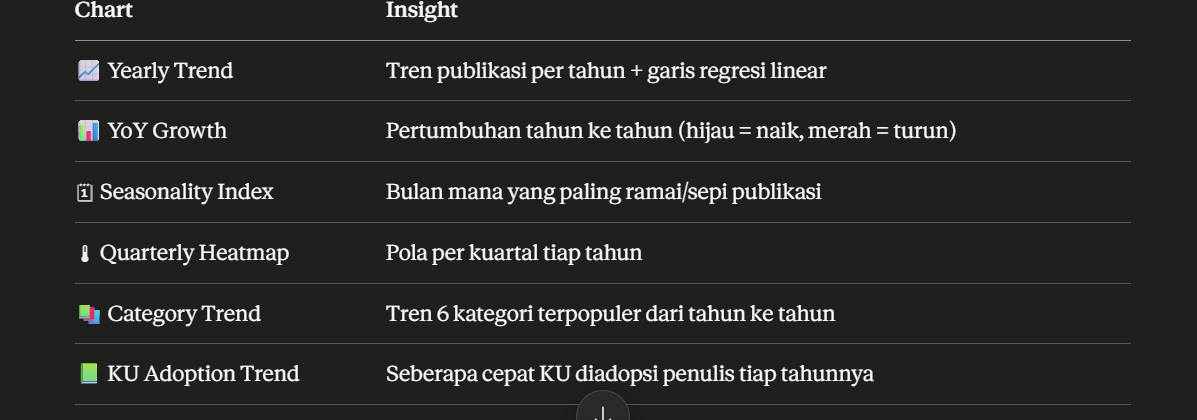

Dataset loaded: 119,611 rows | Columns: ['asin', 'title', 'author', 'soldby', 'imgurl', 'producturl', 'stars', 'reviews', 'price', 'iskindleunlimited', 'category_id', 'isbestseller', 'iseditorspick', 'isgoodreadschoice', 'publisheddate', 'category_name']
Detected → date: publisheddate | rating: stars | reviews: reviews
           category: category_id | KU: iskindleunlimited

Date range : 2000-01-01 → 2024-01-16
Total books (with valid date): 71,742

═════════════════════════════════════════════════════════════════
  YEARLY PUBLICATION TREND
═════════════════════════════════════════════════════════════════
Year        Books    YoY %   Avg Rating
----------------------------------------
2000          154        —         4.54
2001          205   +33.1%         4.52
2002          260   +26.8%         4.50
2003          300   +15.4%         4.51
2004          352   +17.3%         4.51
2005          378    +7.4%         4.50
2006          499   +32.0%         4.50
2007          815   +63.3

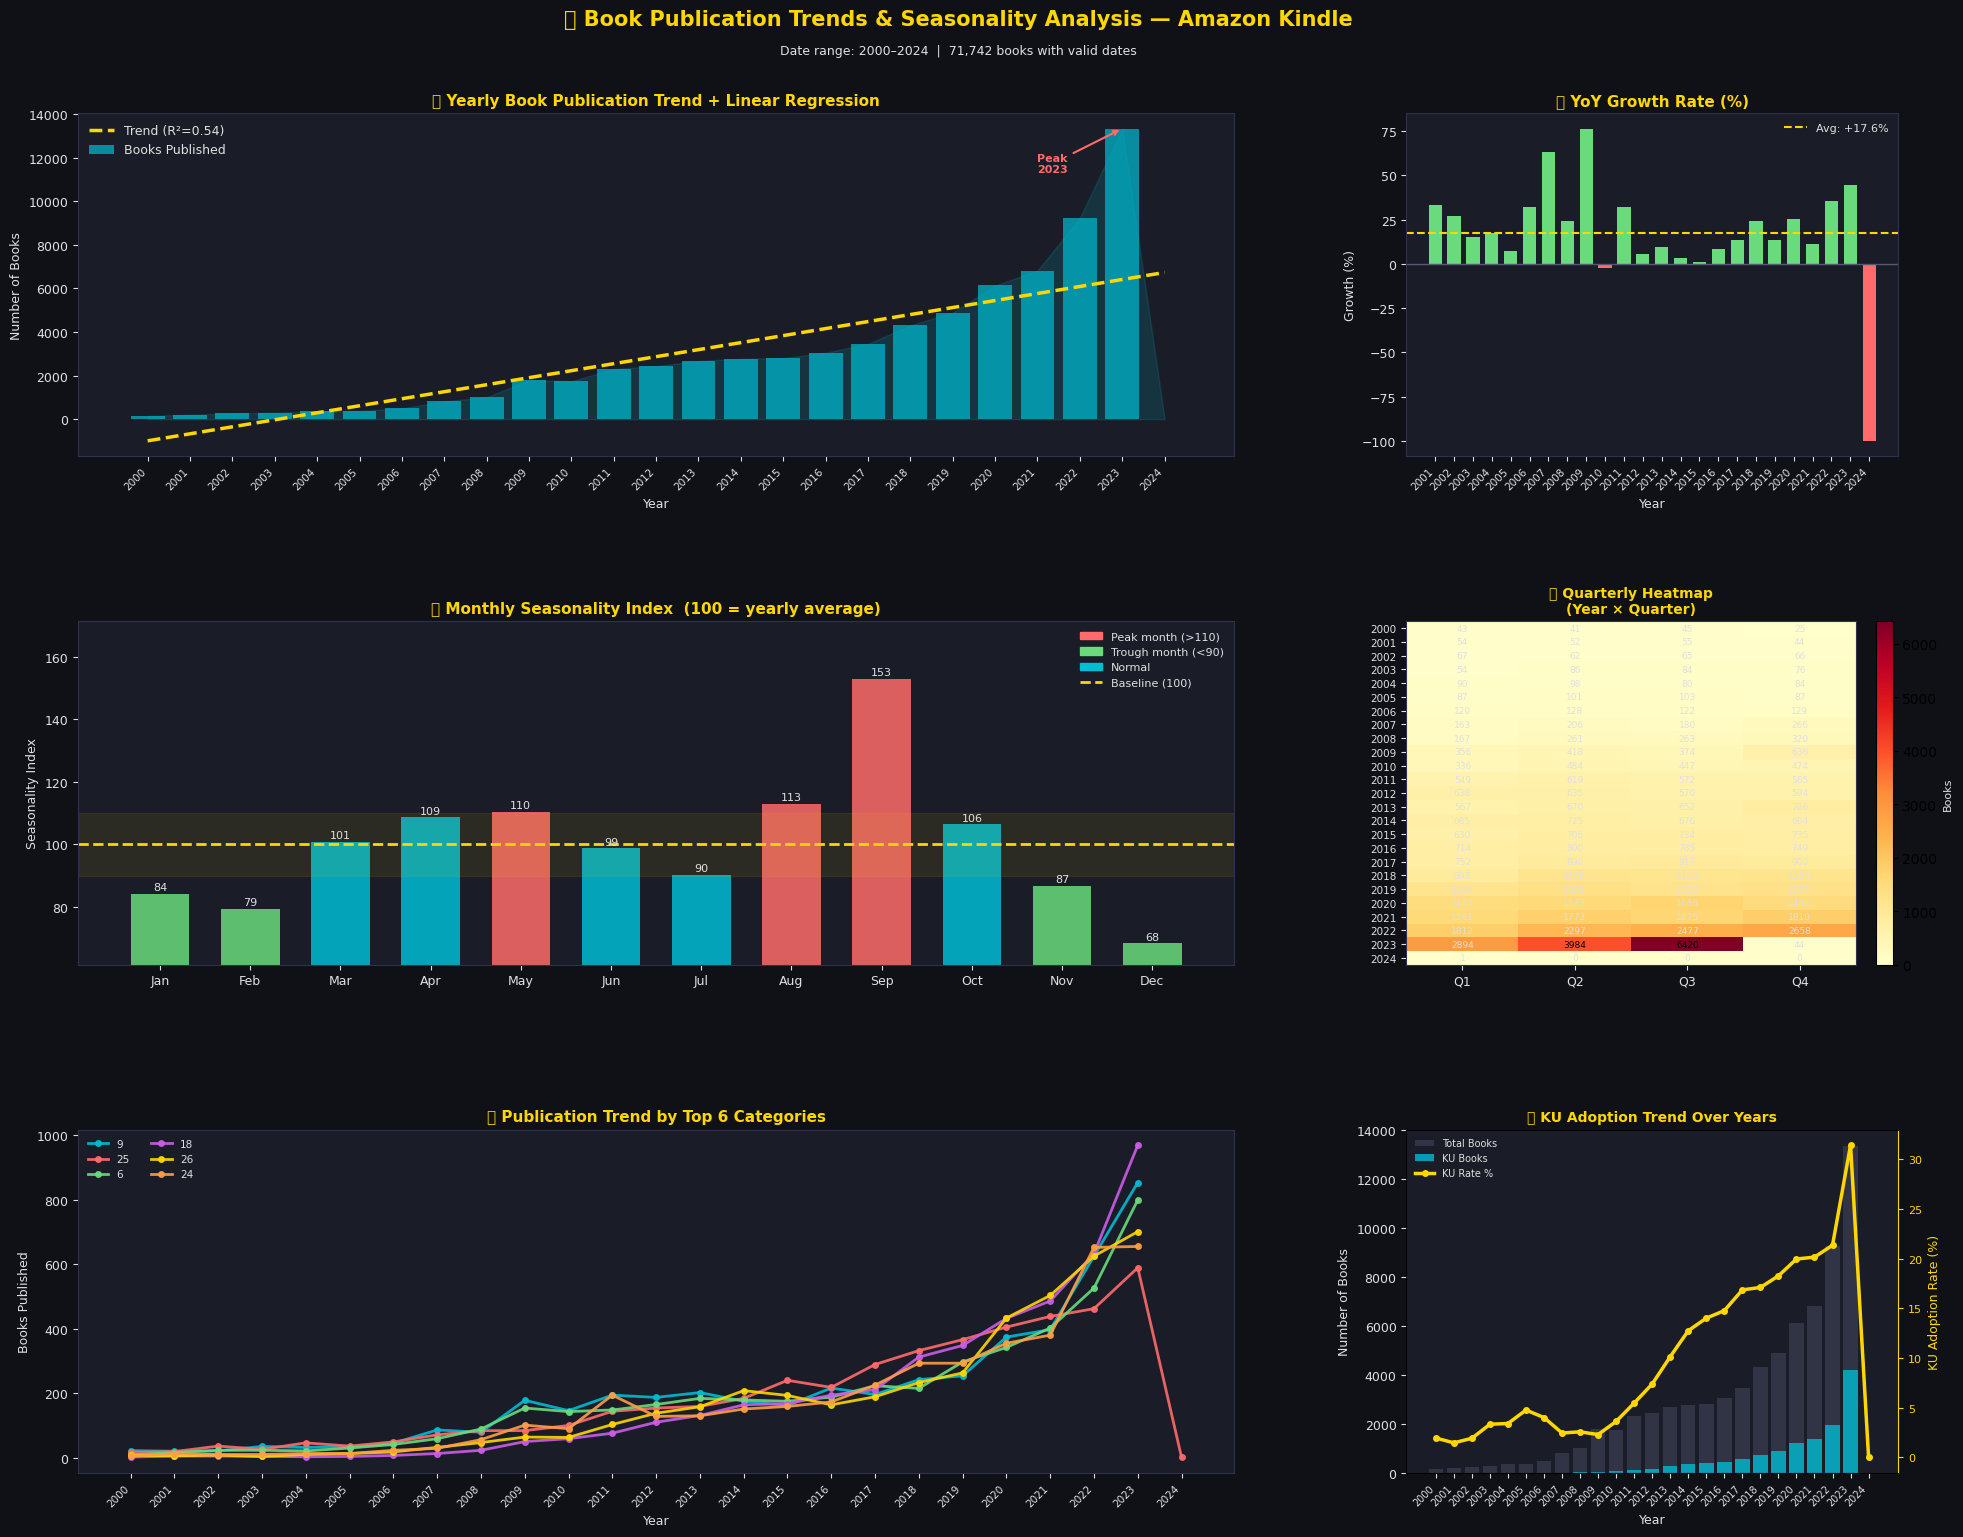


═════════════════════════════════════════════════════════════════
  KESIMPULAN ANALISIS TREN & SEASONALITY
═════════════════════════════════════════════════════════════════

  📈 TREN UMUM
     • Tren linear NAIK dengan R² = 0.544
     • Rata-rata pertumbuhan YoY: +17.6%
     • Tahun puncak publikasi   : 2023

  🗓 SEASONALITY
     • Bulan tersibuk  : Sep (index 153.1)
     • Bulan tersepi   : Dec (index 68.3)
     • Amplitudo musim : 84.8 poin
     • Peak months     : May, Aug, Sep
     • Trough months   : Jan, Feb, Nov, Dec

  📅 QUARTERLY
     • Quarter terkuat : Q3 (Jul-Sep)
     • Quarter terlemah: Q1 (Jan-Mar)

Visualization saved → publication_trends.png


In [6]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ─────────────────────────────────────────────────────────────────
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
clean_file = [f for f in csv_files if 'clean' in f.lower()]
load_file  = clean_file[0] if clean_file else csv_files[0]

df = pd.read_csv(load_file)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w]', '_', regex=True)
print(f"Dataset loaded: {df.shape[0]:,} rows | Columns: {df.columns.tolist()}")

# ── Detect Columns ────────────────────────────────────────────────────────────
date_col     = next((c for c in df.columns if 'date' in c or 'publish' in c or 'release' in c), None)
rating_col   = next((c for c in df.columns if 'star' in c or ('rating' in c and 'count' not in c and 'num' not in c)), None)
reviews_col  = next((c for c in df.columns if 'review' in c or 'ratings_count' in c or 'num_ratings' in c), None)
category_col = next((c for c in df.columns if 'category' in c or 'genre' in c), None)
ku_col       = next((c for c in df.columns if 'kindle_unlimited' in c or 'unlimited' in c), None)
price_col    = next((c for c in df.columns if 'price' in c), None)

print(f"Detected → date: {date_col} | rating: {rating_col} | reviews: {reviews_col}")
print(f"           category: {category_col} | KU: {ku_col}")

# ── Parse Date ────────────────────────────────────────────────────────────────
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', infer_datetime_format=True)
    df = df.dropna(subset=[date_col])
    # Filter tahun yang masuk akal
    df = df[(df[date_col].dt.year >= 2000) & (df[date_col].dt.year <= 2024)]
    df['year']    = df[date_col].dt.year
    df['month']   = df[date_col].dt.month
    df['quarter'] = df[date_col].dt.quarter
    df['month_name']   = df[date_col].dt.strftime('%b')
    df['year_month']   = df[date_col].dt.to_period('M')
    print(f"\nDate range : {df[date_col].min().date()} → {df[date_col].max().date()}")
    print(f"Total books (with valid date): {len(df):,}")
else:
    print("⚠ No date column found!")

for col in [rating_col, reviews_col, price_col]:
    if col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if ku_col:
    df['is_ku'] = df[ku_col].astype(str).str.lower().isin(['true','1','yes'])

# ══════════════════════════════════════════════════════════════════════════════
# ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Yearly Trend ───────────────────────────────────────────────────────────
yearly = df.groupby('year').agg(
    total_books   = ('year', 'count'),
    avg_rating    = (rating_col,  'mean') if rating_col  else ('year', 'count'),
    avg_reviews   = (reviews_col, 'mean') if reviews_col else ('year', 'count'),
).reset_index()

# YoY Growth Rate
yearly['yoy_growth'] = yearly['total_books'].pct_change() * 100

# Linear trend
slope, intercept, r, p, se = stats.linregress(yearly['year'], yearly['total_books'])
yearly['trend_line'] = slope * yearly['year'] + intercept

print("\n" + "═"*65)
print("  YEARLY PUBLICATION TREND")
print("═"*65)
print(f"{'Year':<8} {'Books':>8} {'YoY %':>8} {'Avg Rating':>12}")
print("-"*40)
for _, row in yearly.iterrows():
    yoy = f"{row['yoy_growth']:+.1f}%" if not pd.isna(row['yoy_growth']) else "  —"
    rat = f"{row['avg_rating']:.2f}" if rating_col and not pd.isna(row['avg_rating']) else "N/A"
    print(f"{int(row['year']):<8} {int(row['total_books']):>8,} {yoy:>8} {rat:>12}")

peak_year = yearly.loc[yearly['total_books'].idxmax(), 'year']
best_growth = yearly.loc[yearly['yoy_growth'].idxmax()]
print(f"\n  📈 Peak Year         : {int(peak_year)} ({int(yearly[yearly['year']==peak_year]['total_books'].values[0]):,} books)")
print(f"  🚀 Best Growth Year  : {int(best_growth['year'])} (+{best_growth['yoy_growth']:.1f}%)")
print(f"  📊 Trend R²          : {r**2:.3f}  ({'Strong' if r**2 > 0.7 else 'Moderate' if r**2 > 0.4 else 'Weak'} linear trend)")

# ── 2. Monthly Seasonality ────────────────────────────────────────────────────
monthly_avg = df.groupby('month').agg(
    avg_books   = ('year', 'count'),
    avg_rating  = (rating_col,  'mean') if rating_col  else ('year','count'),
    avg_reviews = (reviews_col, 'mean') if reviews_col else ('year','count'),
).reset_index()
monthly_avg['avg_books'] = monthly_avg['avg_books'] / df['year'].nunique()

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['month_name'] = [MONTH_NAMES[m-1] for m in monthly_avg['month']]

# Seasonality Index = month_avg / overall_avg × 100
overall_monthly_avg = monthly_avg['avg_books'].mean()
monthly_avg['seasonality_index'] = (monthly_avg['avg_books'] / overall_monthly_avg) * 100

# Find peaks & troughs
peaks,  _ = find_peaks(monthly_avg['seasonality_index'].values)
troughs,_ = find_peaks(-monthly_avg['seasonality_index'].values)

print("\n" + "═"*65)
print("  MONTHLY SEASONALITY INDEX  (100 = average)")
print("═"*65)
print(f"{'Month':<8} {'Avg Books/Yr':>13} {'Season. Index':>14} {'Signal':>10}")
print("-"*48)
for _, row in monthly_avg.iterrows():
    idx = row['seasonality_index']
    signal = "🔴 PEAK"   if idx >= 110 else \
             "🟢 TROUGH" if idx <= 90  else \
             "⚪ Normal"
    print(f"{row['month_name']:<8} {row['avg_books']:>13.1f} {idx:>14.1f} {signal:>10}")

peak_month   = monthly_avg.loc[monthly_avg['seasonality_index'].idxmax()]
trough_month = monthly_avg.loc[monthly_avg['seasonality_index'].idxmin()]
print(f"\n  🔴 Highest Season : {peak_month['month_name']}   (index {peak_month['seasonality_index']:.1f})")
print(f"  🟢 Lowest Season  : {trough_month['month_name']}   (index {trough_month['seasonality_index']:.1f})")

# ── 3. Quarterly Pattern ─────────────────────────────────────────────────────
quarterly = df.groupby(['year','quarter']).size().reset_index(name='books')
q_avg = quarterly.groupby('quarter')['books'].mean().reset_index()
q_avg['label'] = ['Q1\n(Jan-Mar)', 'Q2\n(Apr-Jun)', 'Q3\n(Jul-Sep)', 'Q4\n(Oct-Dec)']

print("\n" + "═"*40)
print("  QUARTERLY PATTERN (avg books/year)")
print("═"*40)
for _, row in q_avg.iterrows():
    bar = '█' * int(row['books'] / q_avg['books'].max() * 25)
    print(f"  Q{int(row['quarter'])}: {bar:<25} {row['books']:,.0f}")

# ── 4. Category Trend (if available) ─────────────────────────────────────────
if category_col:
    top_cats = df[category_col].value_counts().head(6).index
    cat_year = df[df[category_col].isin(top_cats)].groupby(
        ['year', category_col]).size().reset_index(name='books')

# ── 5. KU Trend over Years ────────────────────────────────────────────────────
if ku_col:
    ku_yearly = df.groupby('year')['is_ku'].agg(['sum','count']).reset_index()
    ku_yearly.columns = ['year','ku_books','total']
    ku_yearly['ku_rate'] = ku_yearly['ku_books'] / ku_yearly['total'] * 100

# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
BG, CARD   = '#0f1117', '#1a1d27'
GOLD, TEXT = '#FFD700', '#E0E0E0'
TEAL, CORAL= '#00BCD4', '#FF6B6B'
GREEN, PURPLE = '#69DB7C', '#CC5DE8'
GRAY       = '#555870'

fig = plt.figure(figsize=(20, 16), facecolor=BG)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.35,
                        left=0.06, right=0.97, top=0.91, bottom=0.06)

def style_ax(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(GOLD)
    for sp in ax.spines.values():
        sp.set_edgecolor('#2e3250')

# ── Chart 1: Yearly Trend + Linear Regression ────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1)
ax1.bar(yearly['year'], yearly['total_books'], color=TEAL, alpha=0.7, edgecolor='none', label='Books Published')
ax1.plot(yearly['year'], yearly['trend_line'], color=GOLD, linewidth=2.5, linestyle='--', label=f'Trend (R²={r**2:.2f})')
ax1.fill_between(yearly['year'], yearly['total_books'], alpha=0.15, color=TEAL)
# Annotate peak
ax1.annotate(f"Peak\n{int(peak_year)}",
    xy=(peak_year, yearly[yearly['year']==peak_year]['total_books'].values[0]),
    xytext=(peak_year - 2, yearly['total_books'].max() * 0.85),
    color=CORAL, fontsize=8, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.5))
ax1.set_title('📈 Yearly Book Publication Trend + Linear Regression', fontsize=11, fontweight='bold')
ax1.set_xlabel('Year', fontsize=9)
ax1.set_ylabel('Number of Books', fontsize=9)
ax1.legend(fontsize=9, facecolor=CARD, edgecolor='none', labelcolor=TEXT)
ax1.set_xticks(yearly['year'])
ax1.set_xticklabels(yearly['year'].astype(int), rotation=45, ha='right', fontsize=7.5)

# ── Chart 2: YoY Growth Rate ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2)
yoy_data = yearly.dropna(subset=['yoy_growth'])
colors_yoy = [GREEN if v >= 0 else CORAL for v in yoy_data['yoy_growth']]
ax2.bar(yoy_data['year'], yoy_data['yoy_growth'], color=colors_yoy, edgecolor='none', width=0.7)
ax2.axhline(0, color=GRAY, linewidth=1)
ax2.axhline(yoy_data['yoy_growth'].mean(), color=GOLD, linewidth=1.5, linestyle='--',
            label=f"Avg: {yoy_data['yoy_growth'].mean():+.1f}%")
ax2.set_title('📊 YoY Growth Rate (%)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Year', fontsize=9)
ax2.set_ylabel('Growth (%)', fontsize=9)
ax2.set_xticks(yoy_data['year'])
ax2.set_xticklabels(yoy_data['year'].astype(int), rotation=45, ha='right', fontsize=7.5)
ax2.legend(fontsize=8, facecolor=CARD, edgecolor='none', labelcolor=TEXT)

# ── Chart 3: Monthly Seasonality Index ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
style_ax(ax3)
si   = monthly_avg['seasonality_index'].values
clrs = [CORAL if v >= 110 else GREEN if v <= 90 else TEAL for v in si]
bars = ax3.bar(monthly_avg['month_name'], si, color=clrs, edgecolor='none', width=0.65, alpha=0.85)
ax3.axhline(100, color=GOLD, linewidth=2, linestyle='--', label='Baseline (100 = avg)')
ax3.axhspan(90, 110, alpha=0.08, color=GOLD, label='Normal band (90–110)')
for bar, val in zip(bars, si):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=8, color=TEXT)
ax3.set_title('🗓 Monthly Seasonality Index  (100 = yearly average)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Seasonality Index', fontsize=9)
ax3.set_ylim(si.min() * 0.9, si.max() * 1.12)
legend_items = [
    mpatches.Patch(color=CORAL, label='Peak month (>110)'),
    mpatches.Patch(color=GREEN, label='Trough month (<90)'),
    mpatches.Patch(color=TEAL,  label='Normal'),
]
ax3.legend(handles=legend_items + [
    plt.Line2D([0],[0], color=GOLD, linestyle='--', linewidth=2, label='Baseline (100)')],
    fontsize=8, facecolor=CARD, edgecolor='none', labelcolor=TEXT)

# ── Chart 4: Quarterly Heatmap ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
style_ax(ax4)
pivot_q = quarterly.pivot(index='year', columns='quarter', values='books').fillna(0)
im = ax4.imshow(pivot_q.values, aspect='auto', cmap='YlOrRd')
ax4.set_xticks(range(4))
ax4.set_xticklabels(['Q1','Q2','Q3','Q4'], color=TEXT, fontsize=9)
ax4.set_yticks(range(len(pivot_q.index)))
ax4.set_yticklabels(pivot_q.index.astype(int), color=TEXT, fontsize=7.5)
for i in range(len(pivot_q.index)):
    for j in range(4):
        val = pivot_q.values[i, j]
        ax4.text(j, i, f'{int(val)}', ha='center', va='center',
                 fontsize=6.5, color='black' if val > pivot_q.values.max()*0.6 else TEXT)
plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04).set_label('Books', color=TEXT, fontsize=8)
ax4.set_title('🌡 Quarterly Heatmap\n(Year × Quarter)', fontsize=10, fontweight='bold')

# ── Chart 5: Category Trend ───────────────────────────────────────────────────
if category_col:
    ax5 = fig.add_subplot(gs[2, :2])
    style_ax(ax5)
    palette = [TEAL, CORAL, GREEN, PURPLE, GOLD, '#FF9F43']
    for i, cat in enumerate(top_cats):
        sub = cat_year[cat_year[category_col] == cat]
        ax5.plot(sub['year'], sub['books'], marker='o', markersize=4,
                 linewidth=2, color=palette[i % len(palette)],
                 label=str(cat)[:22], alpha=0.9)
    ax5.set_title('📚 Publication Trend by Top 6 Categories', fontsize=11, fontweight='bold')
    ax5.set_xlabel('Year', fontsize=9)
    ax5.set_ylabel('Books Published', fontsize=9)
    ax5.legend(fontsize=7.5, facecolor=CARD, edgecolor='none', labelcolor=TEXT,
               loc='upper left', ncol=2)
    ax5.set_xticks(yearly['year'])
    ax5.set_xticklabels(yearly['year'].astype(int), rotation=45, ha='right', fontsize=7.5)

# ── Chart 6: KU Adoption Trend ───────────────────────────────────────────────
if ku_col:
    ax6 = fig.add_subplot(gs[2, 2])
    style_ax(ax6)
    ax6_twin = ax6.twinx()
    ax6.bar(ku_yearly['year'], ku_yearly['total'], color=GRAY, alpha=0.4, edgecolor='none', label='Total Books')
    ax6.bar(ku_yearly['year'], ku_yearly['ku_books'], color=TEAL, alpha=0.8, edgecolor='none', label='KU Books')
    ax6_twin.plot(ku_yearly['year'], ku_yearly['ku_rate'], color=GOLD,
                  linewidth=2.5, marker='o', markersize=4, label='KU Rate %')
    ax6.set_title('📗 KU Adoption Trend Over Years', fontsize=10, fontweight='bold')
    ax6.set_xlabel('Year', fontsize=9)
    ax6.set_ylabel('Number of Books', fontsize=9, color=TEXT)
    ax6_twin.set_ylabel('KU Adoption Rate (%)', fontsize=9, color=GOLD)
    ax6_twin.tick_params(colors=GOLD, labelsize=8)
    ax6_twin.spines['right'].set_edgecolor(GOLD)
    ax6.set_xticks(ku_yearly['year'])
    ax6.set_xticklabels(ku_yearly['year'].astype(int), rotation=45, ha='right', fontsize=7)
    lines1, labels1 = ax6.get_legend_handles_labels()
    lines2, labels2 = ax6_twin.get_legend_handles_labels()
    ax6.legend(lines1 + lines2, labels1 + labels2,
               fontsize=7, facecolor=CARD, edgecolor='none', labelcolor=TEXT)
elif category_col is None:
    # Fallback: Quarterly avg bar
    ax6 = fig.add_subplot(gs[2, 2])
    style_ax(ax6)
    ax6.bar(q_avg['label'], q_avg['books'], color=[TEAL,GREEN,CORAL,PURPLE], edgecolor='none', width=0.5)
    for i, (_, row) in enumerate(q_avg.iterrows()):
        ax6.text(i, row['books'] + 0.5, f"{row['books']:.0f}", ha='center', fontsize=9, color=TEXT)
    ax6.set_title('📅 Avg Books per Quarter', fontsize=10, fontweight='bold')
    ax6.set_ylabel('Avg Books / Year', fontsize=9)

# ── Main Title ────────────────────────────────────────────────────────────────
fig.text(0.5, 0.965, '📅 Book Publication Trends & Seasonality Analysis — Amazon Kindle',
         ha='center', fontsize=15, fontweight='bold', color=GOLD)
fig.text(0.5, 0.947,
         f"Date range: {df[date_col].min().year}–{df[date_col].max().year}  |  "
         f"{len(df):,} books with valid dates",
         ha='center', fontsize=9, color=TEXT)

plt.savefig("publication_trends.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FINAL CONCLUSIONS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  KESIMPULAN ANALISIS TREN & SEASONALITY")
print("═"*65)
print(f"\n  📈 TREN UMUM")
print(f"     • Tren linear {'NAIK' if slope > 0 else 'TURUN'} dengan R² = {r**2:.3f}")
print(f"     • Rata-rata pertumbuhan YoY: {yoy_data['yoy_growth'].mean():+.1f}%")
print(f"     • Tahun puncak publikasi   : {int(peak_year)}")

print(f"\n  🗓 SEASONALITY")
print(f"     • Bulan tersibuk  : {peak_month['month_name']} (index {peak_month['seasonality_index']:.1f})")
print(f"     • Bulan tersepi   : {trough_month['month_name']} (index {trough_month['seasonality_index']:.1f})")
print(f"     • Amplitudo musim : {peak_month['seasonality_index'] - trough_month['seasonality_index']:.1f} poin")

strong = monthly_avg[monthly_avg['seasonality_index'] >= 110]['month_name'].tolist()
weak   = monthly_avg[monthly_avg['seasonality_index'] <= 90]['month_name'].tolist()
if strong: print(f"     • Peak months     : {', '.join(strong)}")
if weak:   print(f"     • Trough months   : {', '.join(weak)}")

print(f"\n  📅 QUARTERLY")
best_q  = q_avg.loc[q_avg['books'].idxmax(), 'label'].replace('\n',' ')
worst_q = q_avg.loc[q_avg['books'].idxmin(), 'label'].replace('\n',' ')
print(f"     • Quarter terkuat : {best_q}")
print(f"     • Quarter terlemah: {worst_q}")
print(f"\nVisualization saved → publication_trends.png")

Dive into specific book genres to understand their sales performance and popularity.

Dataset loaded: 119,611 rows | Columns: ['asin', 'title', 'author', 'soldby', 'imgurl', 'producturl', 'stars', 'reviews', 'price', 'iskindleunlimited', 'category_id', 'isbestseller', 'iseditorspick', 'isgoodreadschoice', 'publisheddate', 'category_name']
Detected → category: category_id | rating: stars | reviews: reviews
           price: price | KU: iskindleunlimited

═════════════════════════════════════════════════════════════════════════════════════
  GENRE PERFORMANCE REPORT — Amazon Kindle Books
═════════════════════════════════════════════════════════════════════════════════════
Rank  Genre                              Books    Avg⭐   Avg Reviews  Avg Price  Pop.Index
─────────────────────────────────────────────────────────────────────────────────────
1     5.0                                4,139    4.47         9,195      $7.30       79.6
2     16.0                               5,688    4.52         3,014      $7.35       61.6
3     30.0                               4,887  

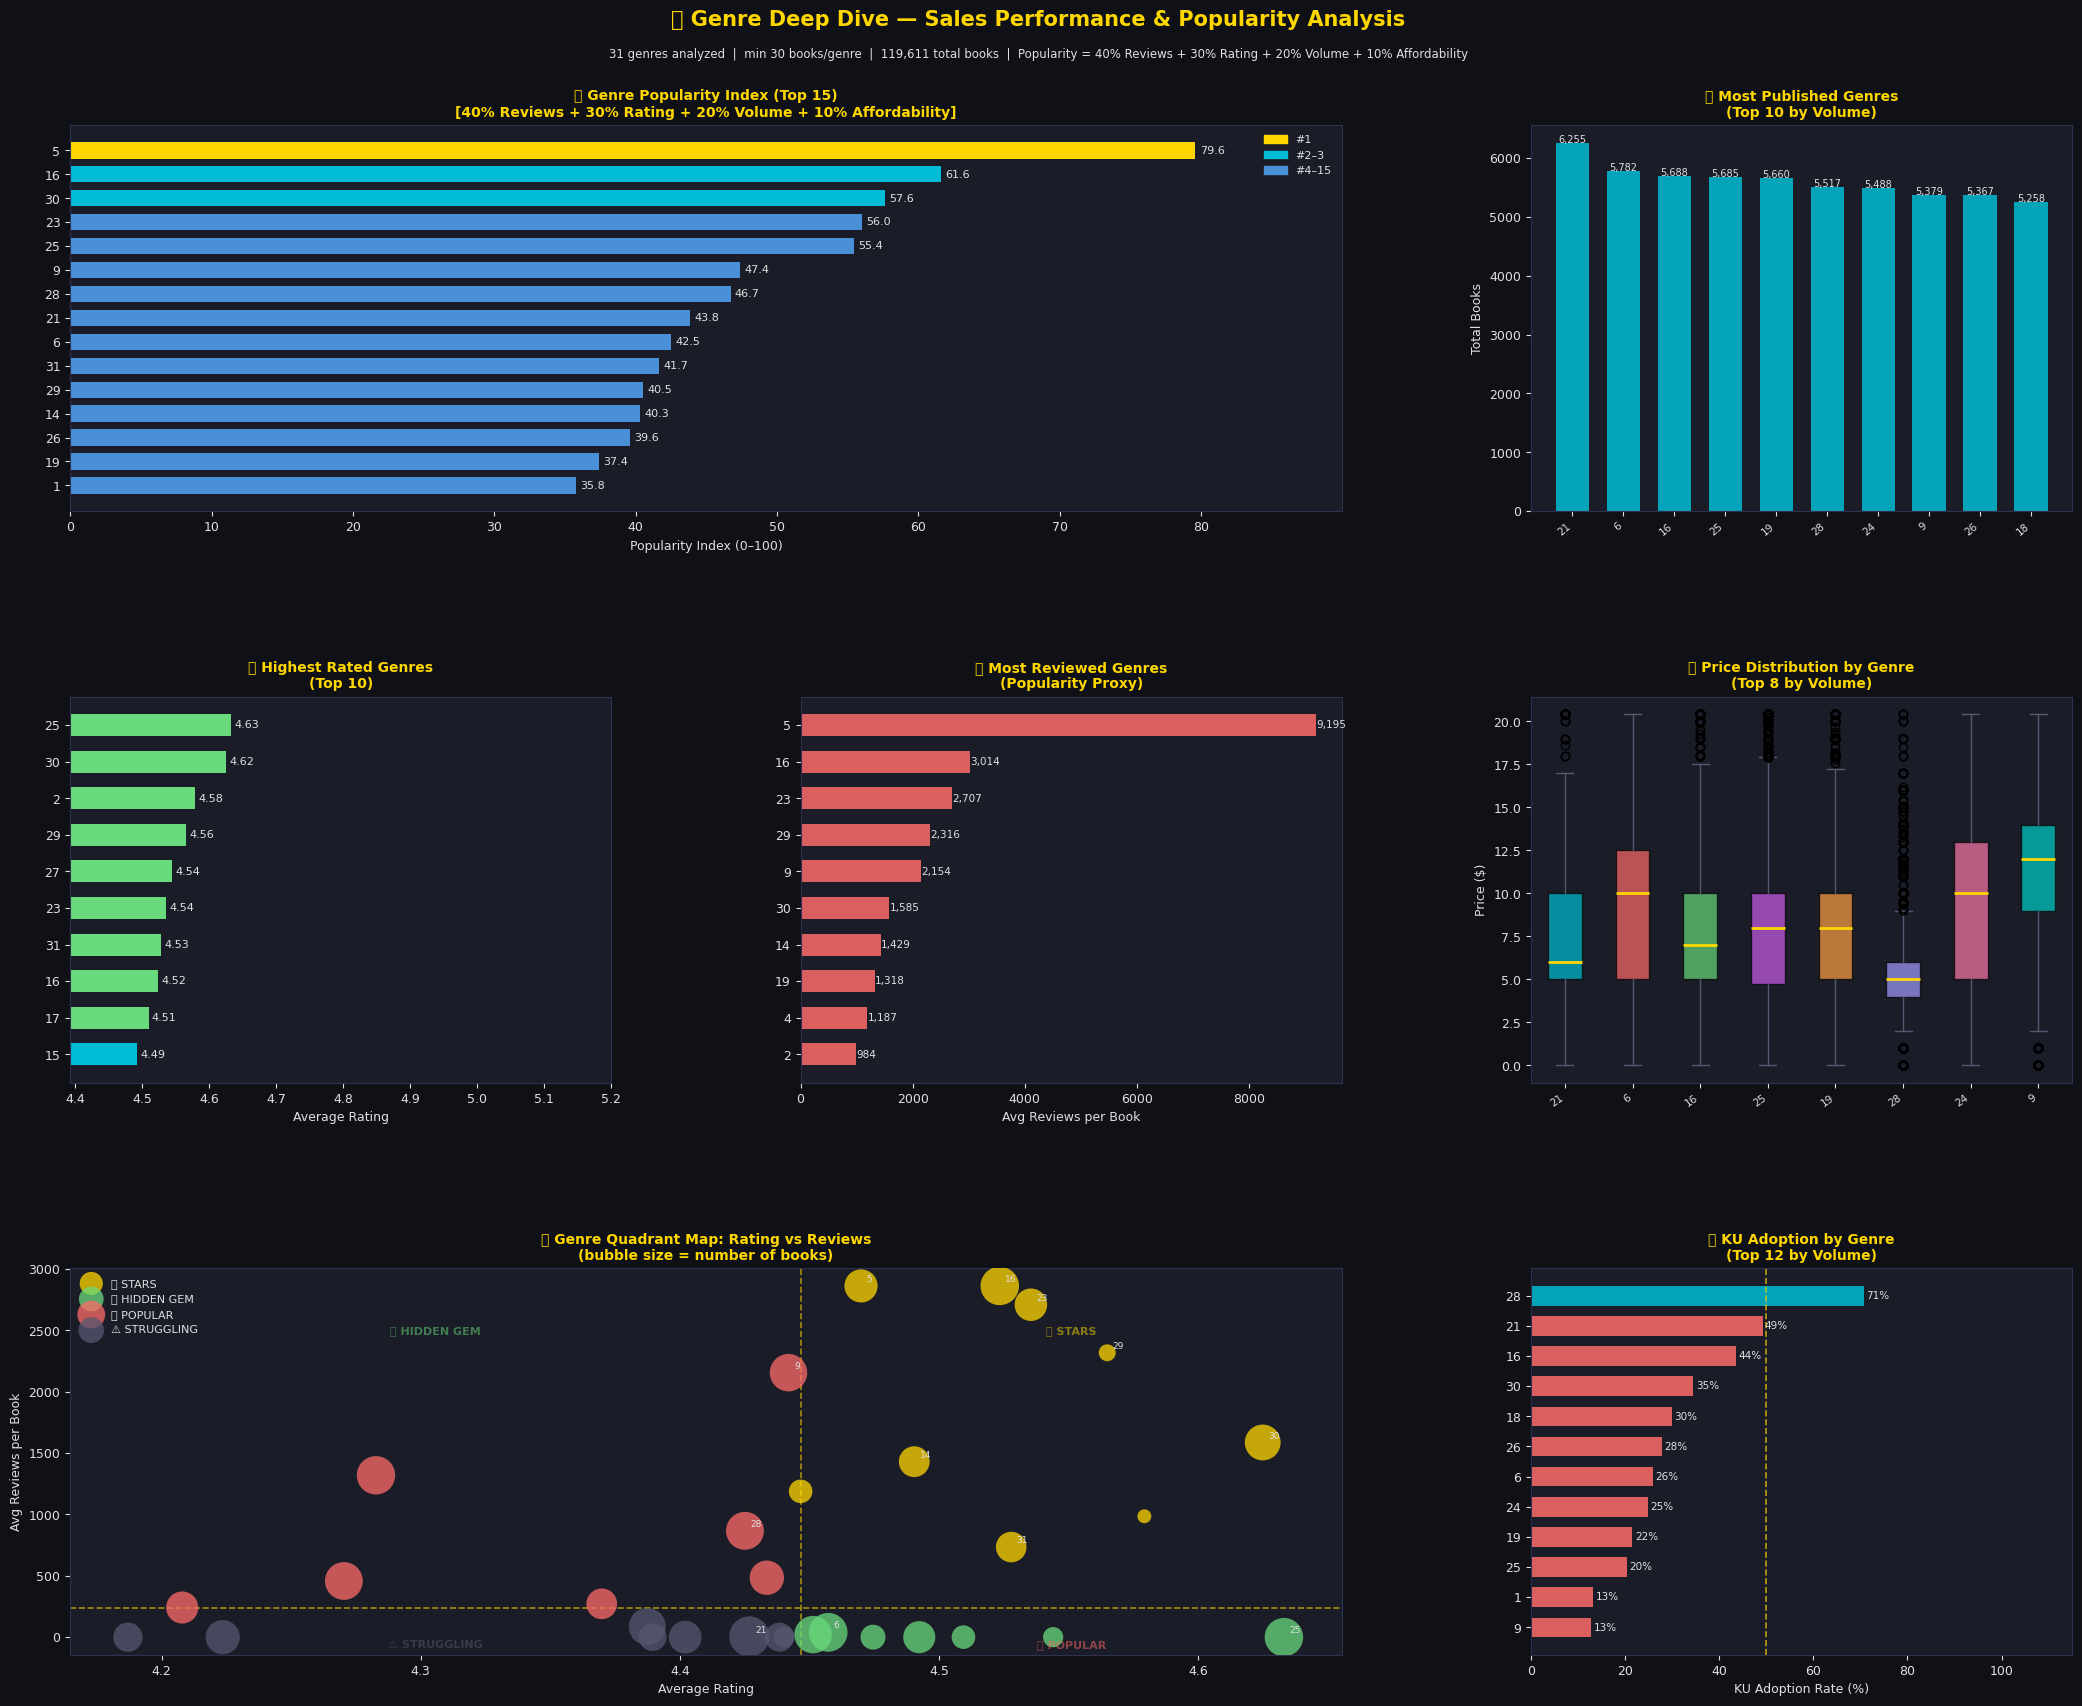


Visualization saved → genre_analysis.png


In [7]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ─────────────────────────────────────────────────────────────────
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
clean_file = [f for f in csv_files if 'clean' in f.lower()]
load_file  = clean_file[0] if clean_file else csv_files[0]

df = pd.read_csv(load_file)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w]', '_', regex=True)
print(f"Dataset loaded: {df.shape[0]:,} rows | Columns: {df.columns.tolist()}")

# ── Detect Columns ────────────────────────────────────────────────────────────
category_col = next((c for c in df.columns if 'category' in c or 'genre' in c), None)
rating_col   = next((c for c in df.columns if 'star' in c or ('rating' in c and 'count' not in c and 'num' not in c)), None)
reviews_col  = next((c for c in df.columns if 'review' in c or 'ratings_count' in c or 'num_ratings' in c), None)
price_col    = next((c for c in df.columns if 'price' in c), None)
ku_col       = next((c for c in df.columns if 'kindle_unlimited' in c or 'unlimited' in c), None)
author_col   = next((c for c in df.columns if 'author' in c), None)
title_col    = next((c for c in df.columns if 'title' in c), None)
date_col     = next((c for c in df.columns if 'date' in c or 'publish' in c), None)

print(f"Detected → category: {category_col} | rating: {rating_col} | reviews: {reviews_col}")
print(f"           price: {price_col} | KU: {ku_col}")

# ── Convert Numerics ──────────────────────────────────────────────────────────
for col in [rating_col, reviews_col, price_col]:
    if col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if ku_col:
    df['is_ku'] = df[ku_col].astype(str).str.lower().isin(['true','1','yes'])

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df['year'] = df[date_col].dt.year

# ══════════════════════════════════════════════════════════════════════════════
# HELPER: Min-Max Normalization
# ══════════════════════════════════════════════════════════════════════════════
def minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng * 100 if rng > 0 else pd.Series([50]*len(s), index=s.index)

# ══════════════════════════════════════════════════════════════════════════════
# GENRE ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
MIN_BOOKS = 30  # minimum books per genre for analysis

genre_stats = df.groupby(category_col).agg(
    total_books    = (title_col   if title_col   else category_col, 'count'),
    avg_rating     = (rating_col,  'mean') if rating_col  else (category_col, 'count'),
    median_rating  = (rating_col,  'median') if rating_col else (category_col, 'count'),
    avg_reviews    = (reviews_col, 'mean')  if reviews_col else (category_col, 'count'),
    total_reviews  = (reviews_col, 'sum')   if reviews_col else (category_col, 'count'),
    avg_price      = (price_col,   'mean')  if price_col   else (category_col, 'count'),
    median_price   = (price_col,   'median') if price_col  else (category_col, 'count'),
).reset_index()

# Filter minimum books
genre_stats = genre_stats[genre_stats['total_books'] >= MIN_BOOKS].copy()

# ── KU Adoption per Genre ─────────────────────────────────────────────────────
if ku_col:
    ku_genre = df.groupby(category_col)['is_ku'].mean().reset_index()
    ku_genre.columns = [category_col, 'ku_rate']
    genre_stats = genre_stats.merge(ku_genre, on=category_col, how='left')

# ── Genre Score (Popularity Index) ───────────────────────────────────────────
# Popularity Proxy = reviews (40%) + rating (30%) + volume (20%) + affordability (10%)
genre_stats['norm_reviews']  = minmax(genre_stats['avg_reviews'])
genre_stats['norm_rating']   = minmax(genre_stats['avg_rating'])
genre_stats['norm_volume']   = minmax(genre_stats['total_books'])
genre_stats['norm_afford']   = 100 - minmax(genre_stats['avg_price']) if price_col else 50

genre_stats['popularity_index'] = (
    0.40 * genre_stats['norm_reviews'] +
    0.30 * genre_stats['norm_rating']  +
    0.20 * genre_stats['norm_volume']  +
    0.10 * genre_stats['norm_afford']
)

genre_stats = genre_stats.sort_values('popularity_index', ascending=False).reset_index(drop=True)
genre_stats.index += 1

TOP_N = 15
top_genres = genre_stats.head(TOP_N).copy()

# ══════════════════════════════════════════════════════════════════════════════
# PRINT REPORT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*85)
print("  GENRE PERFORMANCE REPORT — Amazon Kindle Books")
print("═"*85)
print(f"{'Rank':<5} {'Genre':<32} {'Books':>7} {'Avg⭐':>7} {'Avg Reviews':>13} {'Avg Price':>10} {'Pop.Index':>10}")
print("─"*85)
for rank, row in top_genres.iterrows():
    price_str = f"${row['avg_price']:.2f}" if price_col else "N/A"
    print(f"{rank:<5} {str(row[category_col])[:31]:<32} "
          f"{int(row['total_books']):>7,} "
          f"{row['avg_rating']:>7.2f} "
          f"{int(row['avg_reviews'] or 0):>13,} "
          f"{price_str:>10} "
          f"{row['popularity_index']:>10.1f}")

# Key insights
print("\n" + "═"*65)
print("  KEY INSIGHTS PER DIMENSION")
print("═"*65)
print(f"\n  📚 Most Books Published  : {genre_stats.nlargest(1,'total_books').iloc[0][category_col]}"
      f" ({int(genre_stats.nlargest(1,'total_books').iloc[0]['total_books']):,} books)")
print(f"  ⭐ Highest Avg Rating    : {genre_stats.nlargest(1,'avg_rating').iloc[0][category_col]}"
      f" ({genre_stats.nlargest(1,'avg_rating').iloc[0]['avg_rating']:.2f}⭐)")
print(f"  💬 Most Reviewed Genre   : {genre_stats.nlargest(1,'avg_reviews').iloc[0][category_col]}"
      f" ({int(genre_stats.nlargest(1,'avg_reviews').iloc[0]['avg_reviews'] or 0):,} avg reviews)")
if price_col:
    print(f"  💰 Most Expensive Genre  : {genre_stats.nlargest(1,'avg_price').iloc[0][category_col]}"
          f" (${genre_stats.nlargest(1,'avg_price').iloc[0]['avg_price']:.2f})")
    print(f"  🎁 Most Affordable Genre : {genre_stats.nsmallest(1,'avg_price').iloc[0][category_col]}"
          f" (${genre_stats.nsmallest(1,'avg_price').iloc[0]['avg_price']:.2f})")
if ku_col:
    print(f"  📗 Highest KU Adoption   : {genre_stats.nlargest(1,'ku_rate').iloc[0][category_col]}"
          f" ({genre_stats.nlargest(1,'ku_rate').iloc[0]['ku_rate']*100:.1f}%)")

# Rating distribution per top genre
print(f"\n  ⭐ RATING BREAKDOWN (Top 10 Genres)")
print(f"  {'Genre':<30} {'Mean':>6} {'Median':>8} {'Books':>8}")
print(f"  {'─'*55}")
for _, row in genre_stats.head(10).iterrows():
    bar = '★' * int(row['avg_rating'])
    print(f"  {str(row[category_col])[:29]:<30} {row['avg_rating']:>6.2f} "
          f"{row['median_rating']:>8.2f} {int(row['total_books']):>8,}")

# ══════════════════════════════════════════════════════════════════════════════
# QUADRANT ANALYSIS: Rating vs Reviews
# ══════════════════════════════════════════════════════════════════════════════
med_rating  = genre_stats['avg_rating'].median()
med_reviews = genre_stats['avg_reviews'].median()

def get_quadrant(r, rv):
    if r >= med_rating and rv >= med_reviews: return "⭐ STARS"       # high rating, high reviews
    if r >= med_rating and rv <  med_reviews: return "💎 HIDDEN GEM"  # high rating, low reviews
    if r <  med_rating and rv >= med_reviews: return "📢 POPULAR"     # low rating, high reviews
    return                                           "⚠️ STRUGGLING"  # low rating, low reviews

genre_stats['quadrant'] = genre_stats.apply(
    lambda x: get_quadrant(x['avg_rating'], x['avg_reviews']), axis=1)

print(f"\n  🔲 QUADRANT ANALYSIS")
for q in ["⭐ STARS", "💎 HIDDEN GEM", "📢 POPULAR", "⚠️ STRUGGLING"]:
    genres_in_q = genre_stats[genre_stats['quadrant'] == q][category_col].head(3).tolist()
    print(f"  {q:<18}: {', '.join([str(g)[:20] for g in genres_in_q])}")

# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
BG, CARD     = '#0f1117', '#1a1d27'
GOLD, TEXT   = '#FFD700', '#E0E0E0'
TEAL, CORAL  = '#00BCD4', '#FF6B6B'
GREEN, PURPLE= '#69DB7C', '#CC5DE8'
GRAY         = '#555870'

QUAD_COLORS = {
    "⭐ STARS"      : GOLD,
    "💎 HIDDEN GEM" : GREEN,
    "📢 POPULAR"    : CORAL,
    "⚠️ STRUGGLING" : GRAY,
}

fig = plt.figure(figsize=(22, 18), facecolor=BG)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.35,
                        left=0.06, right=0.97, top=0.91, bottom=0.06)

def style_ax(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(GOLD)
    for sp in ax.spines.values():
        sp.set_edgecolor('#2e3250')

# ── 1. Popularity Index (Top 15) ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1)
colors_pi = [GOLD if i == 0 else TEAL if i < 3 else '#4a90d9' for i in range(len(top_genres))]
names_pi  = [str(n)[:30] for n in top_genres[category_col]]
vals_pi   = top_genres['popularity_index'].values
bars = ax1.barh(names_pi[::-1], vals_pi[::-1], color=colors_pi[::-1], edgecolor='none', height=0.68)
for bar, val in zip(bars, vals_pi[::-1]):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=8, color=TEXT)
ax1.set_title('🏆 Genre Popularity Index (Top 15)\n[40% Reviews + 30% Rating + 20% Volume + 10% Affordability]',
              fontsize=10, fontweight='bold')
ax1.set_xlabel('Popularity Index (0–100)', fontsize=9)
ax1.set_xlim(0, vals_pi.max() * 1.13)
legend_items = [mpatches.Patch(color=GOLD,    label='#1'),
                mpatches.Patch(color=TEAL,    label='#2–3'),
                mpatches.Patch(color='#4a90d9',label='#4–15')]
ax1.legend(handles=legend_items, fontsize=8, facecolor=CARD, edgecolor='none', labelcolor=TEXT)

# ── 2. Total Books per Genre ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2)
top10_vol = genre_stats.nlargest(10, 'total_books')
ax2.bar(range(len(top10_vol)), top10_vol['total_books'],
        color=TEAL, edgecolor='none', width=0.65, alpha=0.85)
ax2.set_xticks(range(len(top10_vol)))
ax2.set_xticklabels([str(g)[:13] for g in top10_vol[category_col]],
                    rotation=40, ha='right', fontsize=7.5)
for i, v in enumerate(top10_vol['total_books']):
    ax2.text(i, v + 5, f'{int(v):,}', ha='center', fontsize=7, color=TEXT)
ax2.set_title('📚 Most Published Genres\n(Top 10 by Volume)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Total Books', fontsize=9)

# ── 3. Avg Rating per Genre ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3)
top10_rating = genre_stats.nlargest(10, 'avg_rating')
colors_r = [GOLD if r >= 4.7 else GREEN if r >= 4.5 else TEAL for r in top10_rating['avg_rating']]
ax3.barh([str(g)[:22] for g in top10_rating[category_col]][::-1],
         top10_rating['avg_rating'].values[::-1],
         color=colors_r[::-1], edgecolor='none', height=0.6)
ax3.set_xlim(top10_rating['avg_rating'].min() - 0.1, 5.2)
for i, (_, row) in enumerate(top10_rating.iloc[::-1].iterrows()):
    ax3.text(row['avg_rating'] + 0.005, i, f"{row['avg_rating']:.2f}",
             va='center', fontsize=8, color=TEXT)
ax3.set_title('⭐ Highest Rated Genres\n(Top 10)', fontsize=10, fontweight='bold')
ax3.set_xlabel('Average Rating', fontsize=9)

# ── 4. Avg Reviews per Genre ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4)
top10_rev = genre_stats.nlargest(10, 'avg_reviews')
ax4.barh([str(g)[:22] for g in top10_rev[category_col]][::-1],
         top10_rev['avg_reviews'].values[::-1],
         color=CORAL, edgecolor='none', height=0.6, alpha=0.85)
for i, (_, row) in enumerate(top10_rev.iloc[::-1].iterrows()):
    ax4.text(row['avg_reviews'] + 5, i, f"{int(row['avg_reviews'] or 0):,}",
             va='center', fontsize=7.5, color=TEXT)
ax4.set_title('💬 Most Reviewed Genres\n(Popularity Proxy)', fontsize=10, fontweight='bold')
ax4.set_xlabel('Avg Reviews per Book', fontsize=9)

# ── 5. Price Boxplot per Genre ────────────────────────────────────────────────
if price_col:
    ax5 = fig.add_subplot(gs[1, 2])
    style_ax(ax5)
    top8_price = genre_stats.nlargest(8, 'total_books')[category_col].tolist()
    price_data = [df[df[category_col] == g][price_col].dropna().clip(upper=df[price_col].quantile(0.95)).values
                  for g in top8_price]
    price_data = [p for p in price_data if len(p) > 0]
    bp = ax5.boxplot(price_data, patch_artist=True, widths=0.5,
                     medianprops={'color': GOLD, 'linewidth': 2})
    colors_bp = [TEAL, CORAL, GREEN, PURPLE, '#FF9F43', '#A29BFE', '#FD79A8', '#00CEC9']
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    for element in ['whiskers','caps','fliers']:
        for item in bp[element]:
            item.set_color(GRAY)
    ax5.set_xticks(range(1, len(top8_price)+1))
    ax5.set_xticklabels([str(g)[:11] for g in top8_price[:len(price_data)]],
                        rotation=35, ha='right', fontsize=7.5)
    ax5.set_title('💰 Price Distribution by Genre\n(Top 8 by Volume)', fontsize=10, fontweight='bold')
    ax5.set_ylabel('Price ($)', fontsize=9)

# ── 6. Quadrant Scatter ───────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :2])
style_ax(ax6)
cap_reviews = genre_stats['avg_reviews'].quantile(0.95)
for quad, color in QUAD_COLORS.items():
    sub = genre_stats[genre_stats['quadrant'] == quad]
    ax6.scatter(sub['avg_rating'],
                sub['avg_reviews'].clip(upper=cap_reviews),
                s=sub['total_books'] / genre_stats['total_books'].max() * 800 + 40,
                c=color, alpha=0.75, edgecolors='none', label=quad, zorder=3)
# Label top genres
for _, row in genre_stats.head(12).iterrows():
    ax6.annotate(str(row[category_col])[:16],
                 (row['avg_rating'], min(row['avg_reviews'] or 0, cap_reviews)),
                 fontsize=6.5, color=TEXT, xytext=(4, 3), textcoords='offset points')
# Quadrant lines
ax6.axvline(med_rating,  color=GOLD, linewidth=1.2, linestyle='--', alpha=0.6)
ax6.axhline(med_reviews, color=GOLD, linewidth=1.2, linestyle='--', alpha=0.6)
# Quadrant labels
ax_xlim = ax6.get_xlim(); ax_ylim = ax6.get_ylim()
quad_labels = [
    (med_rating + (ax_xlim[1]-med_rating)*0.5, med_reviews + (cap_reviews-med_reviews)*0.85, "⭐ STARS",       GOLD),
    (ax_xlim[0] + (med_rating-ax_xlim[0])*0.5, med_reviews + (cap_reviews-med_reviews)*0.85, "💎 HIDDEN GEM",  GREEN),
    (med_rating + (ax_xlim[1]-med_rating)*0.5, ax_ylim[0]  + (med_reviews-ax_ylim[0])*0.15,  "📢 POPULAR",     CORAL),
    (ax_xlim[0] + (med_rating-ax_xlim[0])*0.5, ax_ylim[0]  + (med_reviews-ax_ylim[0])*0.15,  "⚠️ STRUGGLING",  GRAY),
]
for qx, qy, ql, qc in quad_labels:
    ax6.text(qx, qy, ql, ha='center', fontsize=8, color=qc, fontweight='bold', alpha=0.5)
ax6.set_title('🔲 Genre Quadrant Map: Rating vs Reviews\n(bubble size = number of books)',
              fontsize=10, fontweight='bold')
ax6.set_xlabel('Average Rating', fontsize=9)
ax6.set_ylabel('Avg Reviews per Book', fontsize=9)
ax6.legend(fontsize=8, facecolor=CARD, edgecolor='none', labelcolor=TEXT,
           loc='upper left', markerscale=0.8)

# ── 7. KU Adoption by Genre ───────────────────────────────────────────────────
if ku_col:
    ax7 = fig.add_subplot(gs[2, 2])
    style_ax(ax7)
    top12_ku = genre_stats.nlargest(12, 'total_books').sort_values('ku_rate')
    ku_colors = [TEAL if r >= 0.5 else CORAL for r in top12_ku['ku_rate']]
    ax7.barh([str(g)[:22] for g in top12_ku[category_col]],
             top12_ku['ku_rate'] * 100,
             color=ku_colors, edgecolor='none', height=0.65, alpha=0.85)
    ax7.axvline(50, color=GOLD, linestyle='--', linewidth=1.2, alpha=0.7)
    for i, (_, row) in enumerate(top12_ku.iterrows()):
        ax7.text(row['ku_rate']*100 + 0.5, i, f"{row['ku_rate']*100:.0f}%",
                 va='center', fontsize=7.5, color=TEXT)
    ax7.set_title('📗 KU Adoption by Genre\n(Top 12 by Volume)', fontsize=10, fontweight='bold')
    ax7.set_xlabel('KU Adoption Rate (%)', fontsize=9)
    ax7.set_xlim(0, 115)
else:
    # Fallback: Weighted Score Breakdown
    ax7 = fig.add_subplot(gs[2, 2])
    style_ax(ax7)
    top8 = top_genres.head(8)
    x = np.arange(len(top8))
    w = 0.22
    ax7.bar(x - w,   top8['norm_reviews'] * 0.40, width=w, color=CORAL,  label='Reviews×40%', edgecolor='none')
    ax7.bar(x,       top8['norm_rating']  * 0.30, width=w, color=TEAL,   label='Rating×30%',  edgecolor='none')
    ax7.bar(x + w,   top8['norm_volume']  * 0.20, width=w, color=GREEN,  label='Volume×20%',  edgecolor='none')
    ax7.set_xticks(x)
    ax7.set_xticklabels([str(g)[:11] for g in top8[category_col]], rotation=35, ha='right', fontsize=7.5)
    ax7.set_title('⚖️ Score Breakdown (Top 8)', fontsize=10, fontweight='bold')
    ax7.set_ylabel('Weighted Score', fontsize=9)
    ax7.legend(fontsize=7, facecolor=CARD, edgecolor='none', labelcolor=TEXT)

# ── Main Title ────────────────────────────────────────────────────────────────
fig.text(0.5, 0.965, '📖 Genre Deep Dive — Sales Performance & Popularity Analysis',
         ha='center', fontsize=15, fontweight='bold', color=GOLD)
fig.text(0.5, 0.947,
         f"{len(genre_stats):,} genres analyzed  |  min {MIN_BOOKS} books/genre  |  "
         f"{len(df):,} total books  |  Popularity = 40% Reviews + 30% Rating + 20% Volume + 10% Affordability",
         ha='center', fontsize=8.5, color=TEXT)

plt.savefig("genre_analysis.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("\nVisualization saved → genre_analysis.png")